Name: Devang Kishor Wani

Roll No: 66

Division: B

Group No: 03

DOP:

DOS:

Score:


Experiment No 4: Perform exploratory data analysis and visualization of social media data for business.

# Exploratory Data Analysis: MuscleBlaze Social Media & Marketplace Data

**Experiment:** Perform exploratory data analysis and visualization of social media data for business.

**Datasets used:**
- `youtube_cleaned.csv` — MuscleBlaze YouTube channel video performance
- `instagram_cleaned.csv` — MuscleBlaze Instagram posts (Reels/Carousels)
- `amazon_cleaned.csv` — MuscleBlaze product listings on Amazon


## Understand the Problem and the Data

**Goal:** Understand how MuscleBlaze's content performs across YouTube and Instagram, and how its products
are priced and rated on Amazon, in order to surface actionable insights for social media & marketing strategy.


| Dataset | Rows | Grain | Key numeric fields | Key text fields |
|---|---|---|---|---|
| YouTube | 400 | 1 video | `viewCount`, `likes`, `commentsCount`, `numberOfSubscribers` | `title`, `text`, `hashtags` |
| Instagram | 300 | 1 post (Reel/Carousel) | `likesCount`, `commentsCount`, `videoViewCount`, `videoPlayCount` | `caption_clean`, `hashtags`, `mentions` |
| Amazon | 100 | 1 product listing | `price/value`, `stars`, `reviewsCount` | `title`, `description_clean` |


- All three datasets belong to a single brand (**MuscleBlaze**) — there's no cross-brand comparison possible,
  the whole analysis is a single-brand deep-dive.
- YouTube: `hashtags` is an empty list `[]` for 372/400 videos; `channelLocation` is constant (`India`), but
  the *video-level* `location` field takes two values (`India` / `DUBAI`).
- Instagram: several columns are almost entirely null (e.g. `sponsors`, `isPinned`, `taggedUsers`) — this
  reflects that most posts are organic rather than paid partnerships, i.e. it's a real pattern, not corrupted
  data.
- Amazon: `description`/`description_clean` is null for 73/100 rows, and `stars`/`reviewsCount` are null for 7
  rows — most likely newer listings that haven't accumulated reviews yet (data missing *because of* a real
  product attribute, not at random).


# Part 1 — YouTube

## 1. Import and Inspect Data

### Subtask
Load `youtube_cleaned.csv`, check shape, dtypes, missing values, and duplicates.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
from collections import Counter
import ast, ast as _ast, warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

yt = pd.read_csv('youtube_cleaned.csv')
print("Shape:", yt.shape)
display(yt.head())
display(yt.info())
display(yt.isnull().sum())
print("Duplicate rows:", yt.duplicated().sum())

Shape: (400, 27)


,title,type,id,url,viewCount,date,likes,location,channelName,channelUrl,...,channelBannerUrl,channelTotalVideos,channelTotalViews,numberOfSubscribers,aboutChannelInfo,duration,commentsCount,text,hashtags,title_clean
0,Rahul's Journey to a National Record,video,qihLejP9_cY,https://www.youtube.com/watch?v=qihLejP9_cY,5192245,2026-08-08T09:03:44.000Z,59307,India,MuscleBlaze,https://www.youtube.com/channel/UCKlSCO8Tnr1_Q...,...,https://yt3.googleusercontent.com/pwslaCDpj_u6...,1184,587247578,1060000,"{""channelDescription"": ""MuscleBlaze, with its ...",0:03:55,2044,Rahul's Journey to a National Record\n\nFuel y...,[],rahuls journey national record
1,Behind the Scenes: MuscleBlaze Athlete Trainin...,video,L-VLEkZNUI6,https://www.youtube.com/watch?v=L-VLEkZNUI6,24121364,2026-06-10T15:52:04.000Z,401665,India,MuscleBlaze,https://www.youtube.com/channel/UCKlSCO8Tnr1_Q...,...,https://yt3.googleusercontent.com/pwslaCDpj_u6...,1184,587247578,1060000,"{""channelDescription"": ""MuscleBlaze, with its ...",0:05:48,52111,Behind the Scenes: MuscleBlaze Athlete Trainin...,[],behind scenes muscleblaze athlete training camp
2,Tejas's Journey to a National Record,video,GPH0XtV4Dot,https://www.youtube.com/watch?v=GPH0XtV4Dot,46125517,2026-07-10T23:25:49.000Z,181923,DUBAI,MuscleBlaze,https://www.youtube.com/channel/UCKlSCO8Tnr1_Q...,...,https://yt3.googleusercontent.com/pwslaCDpj_u6...,1184,587247578,1060000,"{""channelDescription"": ""MuscleBlaze, with its ...",0:03:49,15093,Tejas's Journey to a National Record\n\nFuel y...,[],tejass journey national record
3,Whey Protein vs Isolate - Which One Should You...,video,WkHG5l1QeHH,https://www.youtube.com/watch?v=WkHG5l1QeHH,42933340,2025-06-19T22:35:32.000Z,418279,DUBAI,MuscleBlaze,https://www.youtube.com/channel/UCKlSCO8Tnr1_Q...,...,https://yt3.googleusercontent.com/pwslaCDpj_u6...,1184,587247578,1060000,"{""channelDescription"": ""MuscleBlaze, with its ...",0:03:38,26800,Whey Protein vs Isolate - Which One Should You...,[],whey protein vs isolate which one should you buy
4,Rohit's Transformation Story | Powered by Musc...,video,YuxpZa--P8s,https://www.youtube.com/watch?v=YuxpZa--P8s,149111041,2025-10-22T02:17:24.000Z,2939899,India,MuscleBlaze,https://www.youtube.com/channel/UCKlSCO8Tnr1_Q...,...,https://yt3.googleusercontent.com/pwslaCDpj_u6...,1184,587247578,1060000,"{""channelDescription"": ""MuscleBlaze, with its ...",0:00:40,252268,Rohit's Transformation Story | Powered by Musc...,[],rohits transformation story powered by muscleb...


<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   title                    400 non-null    str  
 1   type                     400 non-null    str  
 2   id                       400 non-null    str  
 3   url                      400 non-null    str  
 4   viewCount                400 non-null    int64
 5   date                     400 non-null    str  
 6   likes                    400 non-null    int64
 7   location                 400 non-null    str  
 8   channelName              400 non-null    str  
 9   channelUrl               400 non-null    str  
 10  channelUsername          400 non-null    str  
 11  channelId                400 non-null    str  
 12  channelDescription       400 non-null    str  
 13  channelJoinedDate        400 non-null    str  
 14  channelDescriptionLinks  400 non-null    str  
 15  channelLocation  

None

title                      0
type                       0
id                         0
url                        0
viewCount                  0
date                       0
likes                      0
location                   0
channelName                0
channelUrl                 0
channelUsername            0
channelId                  0
channelDescription         0
channelJoinedDate          0
channelDescriptionLinks    0
channelLocation            0
channelAvatarUrl           0
channelBannerUrl           0
channelTotalVideos         0
channelTotalViews          0
numberOfSubscribers        0
aboutChannelInfo           0
duration                   0
commentsCount              0
text                       7
hashtags                   0
title_clean                0
dtype: int64

Duplicate rows: 0


## 2. Handle Missing Data

Only the `text` column (video description) has missing values (7 out of 400 rows — under 2%).
Since a missing description is plausible for a small number of uploads (MCAR-like: no relationship
to view/like counts), and every other engagement metric is complete for these rows, **dropping** them
would throw away good engagement data for no benefit. We instead **impute with an empty string** so
downstream text analysis can safely run over the whole column.

In [ ]:
print("Missing 'text' rows:", yt['text'].isnull().sum(), f"({yt['text'].isnull().mean()*100:.1f}% of data)")
yt['text'] = yt['text'].fillna('')
print("Missing after imputation:", yt['text'].isnull().sum())

Missing 'text' rows: 7 (1.8% of data)
Missing after imputation: 0


## 3. Explore Data Characteristics

Summary statistics (mean, median, std, skewness, kurtosis) for the core engagement metrics, plus the
distribution of the one categorical field that actually varies (`location`).

In [ ]:
numerical_cols = ['viewCount', 'likes', 'commentsCount', 'numberOfSubscribers', 'channelTotalVideos']
display(yt[numerical_cols].describe())

skew_kurt = pd.DataFrame({
    'skewness': yt[numerical_cols].skew(),
    'kurtosis': yt[numerical_cols].kurt()
})
display(skew_kurt)

print("Videos by location:")
display(yt['location'].value_counts())

,viewCount,likes,commentsCount,numberOfSubscribers,channelTotalVideos
count,4.000000e+02,4.000000e+02,400.000000,400.0,400.0
mean,2.560566e+07,2.726369e+05,25697.440000,1060000.0,1184.0
std,3.039407e+07,3.977358e+05,42800.388541,0.0,0.0
min,1.271000e+03,1.400000e+01,0.000000,1060000.0,1184.0
25%,3.645882e+06,1.867325e+04,1023.000000,1060000.0,1184.0
50%,1.532339e+07,1.392675e+05,10238.500000,1060000.0,1184.0
75%,3.529652e+07,3.547828e+05,31267.250000,1060000.0,1184.0
max,1.491110e+08,2.939899e+06,295481.000000,1060000.0,1184.0


,skewness,kurtosis
viewCount,1.891900,3.780830
likes,2.852924,10.839437
commentsCount,3.338155,13.465987
numberOfSubscribers,0.000000,0.000000
channelTotalVideos,0.000000,0.000000


Videos by location:


location
India    340
DUBAI     60
Name: count, dtype: int64

**Reading the numbers:** `viewCount` and `likes` are both heavily right-skewed (skew > 2) — a small
number of videos go viral and pull the mean far above the median. This is normal for social content and
tells us **median**, not mean, is the more honest "typical video" statistic here.

## 4. Perform Data Transformation

- Parse `date` to a real datetime and derive `year`, `month`, `day_of_week`, `hour`.
- Parse `duration` (`H:MM:SS` string) into `duration_seconds`.
- Engineer `total_engagement` and `engagement_rate` (engagement per view) — the two metrics we'll use
  repeatedly in the engagement analysis below.

In [ ]:
yt['date'] = pd.to_datetime(yt['date'])
yt['year'] = yt['date'].dt.year
yt['month'] = yt['date'].dt.month_name()
yt['day_of_week'] = yt['date'].dt.day_name()
yt['hour'] = yt['date'].dt.hour

def to_seconds(t):
    parts = [int(p) for p in str(t).split(':')]
    while len(parts) < 3:
        parts.insert(0, 0)
    h, m, s = parts
    return h * 3600 + m * 60 + s

yt['duration_seconds'] = yt['duration'].apply(to_seconds)
yt['total_engagement'] = yt['likes'] + yt['commentsCount']
yt['engagement_rate'] = yt['total_engagement'] / yt['viewCount']

display(yt[['date', 'year', 'month', 'day_of_week', 'hour', 'duration_seconds',
            'total_engagement', 'engagement_rate']].head())

,date,year,month,day_of_week,hour,duration_seconds,total_engagement,engagement_rate
0,2026-08-08 09:03:44+00:00,2026,August,Saturday,9,235,61351,0.011816
1,2026-06-10 15:52:04+00:00,2026,June,Wednesday,15,348,453776,0.018812
2,2026-07-10 23:25:49+00:00,2026,July,Friday,23,229,197016,0.004271
3,2025-06-19 22:35:32+00:00,2025,June,Thursday,22,218,445079,0.010367
4,2025-10-22 02:17:24+00:00,2025,October,Wednesday,2,40,3192167,0.021408


## 5. Visualize Relationships

### 5.1 Location Analysis (adapted)
YouTube is the one dataset where a location field actually exists at the video level.

,videos,avg_views,avg_likes,avg_engagement_rate
location,,,,
DUBAI,60,2.738519e+07,304592.417,0.014
India,340,2.529163e+07,266997.685,0.013


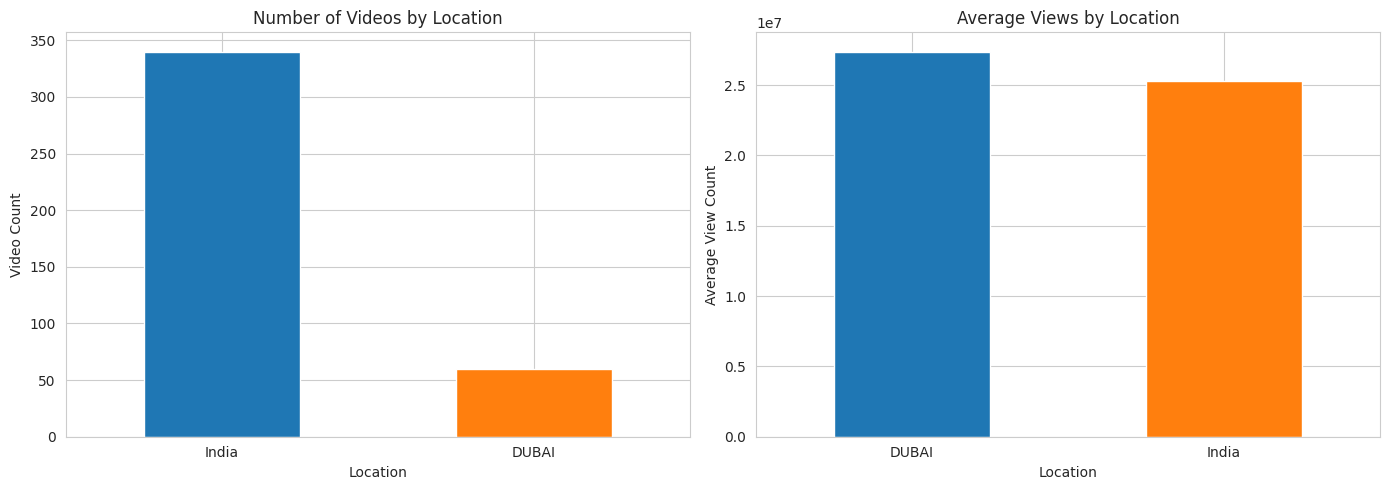

In [ ]:
loc_stats = yt.groupby('location').agg(
    videos=('viewCount', 'count'),
    avg_views=('viewCount', 'mean'),
    avg_likes=('likes', 'mean'),
    avg_engagement_rate=('engagement_rate', 'mean')
).round(3)
display(loc_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
yt['location'].value_counts().plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Number of Videos by Location')
axes[0].set_xlabel('Location'); axes[0].set_ylabel('Video Count')
axes[0].tick_params(axis='x', rotation=0)

yt.groupby('location')['viewCount'].mean().plot(kind='bar', ax=axes[1], color=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Average Views by Location')
axes[1].set_xlabel('Location'); axes[1].set_ylabel('Average View Count')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### 5.2 Text Analysis

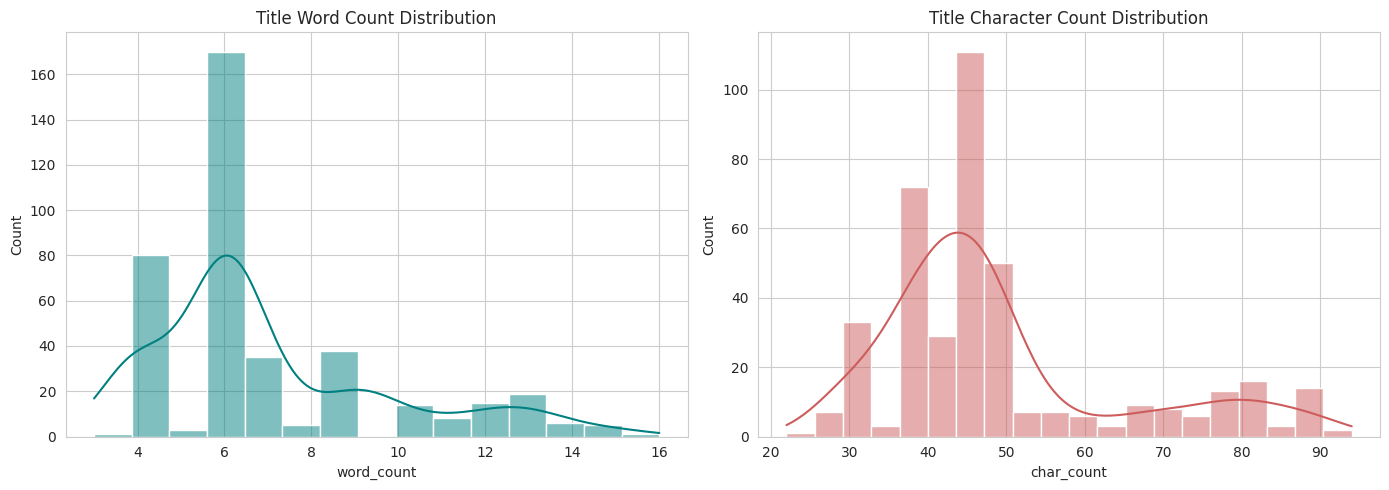

In [ ]:
yt['word_count'] = yt['title_clean'].str.split().str.len()
yt['char_count'] = yt['title_clean'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(yt['word_count'], bins=15, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Title Word Count Distribution')
sns.histplot(yt['char_count'], bins=20, kde=True, ax=axes[1], color='indianred')
axes[1].set_title('Title Character Count Distribution')
plt.tight_layout()
plt.show()

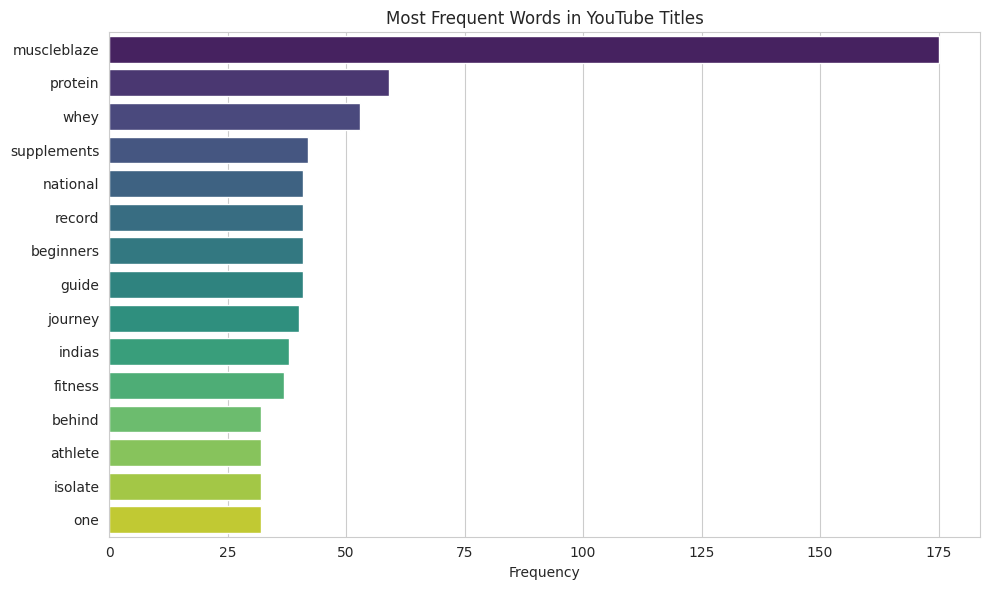

In [ ]:
STOPWORDS = {'the','a','an','is','are','of','to','in','for','and','with','on','at','this','that',
             'i','you','your','it','we','our','be','how','can','my','as','by','from','&','|'}

all_words = ' '.join(yt['title_clean'].dropna()).lower().split()
all_words = [w for w in all_words if w not in STOPWORDS and len(w) > 2]
word_freq = Counter(all_words).most_common(15)

plt.figure(figsize=(10, 6))
words, counts = zip(*word_freq)
sns.barplot(x=list(counts), y=list(words), palette='viridis')
plt.title('Most Frequent Words in YouTube Titles')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

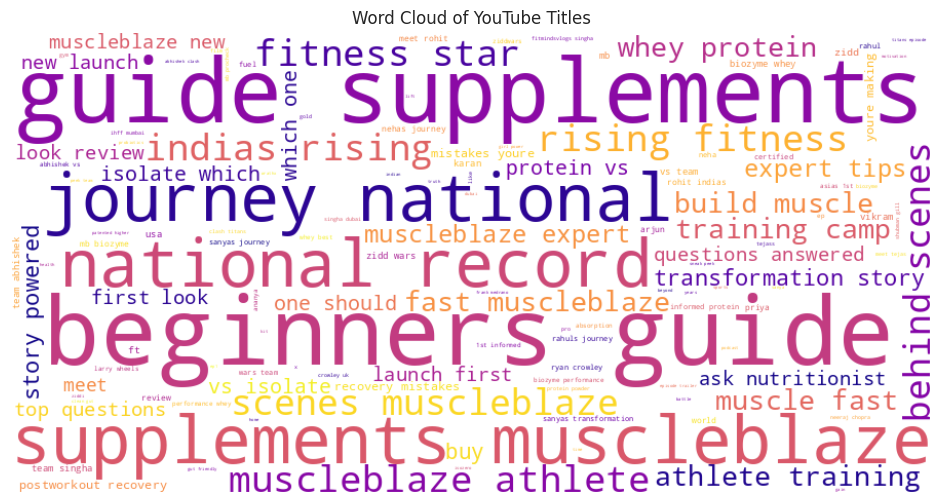

In [ ]:
wc_text = ' '.join(yt['title_clean'].dropna())
wordcloud = WordCloud(width=900, height=450, background_color='white',
                       stopwords=STOPWORDS, colormap='plasma').generate(wc_text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of YouTube Titles')
plt.show()

Videos with at least one hashtag: 28 / 400


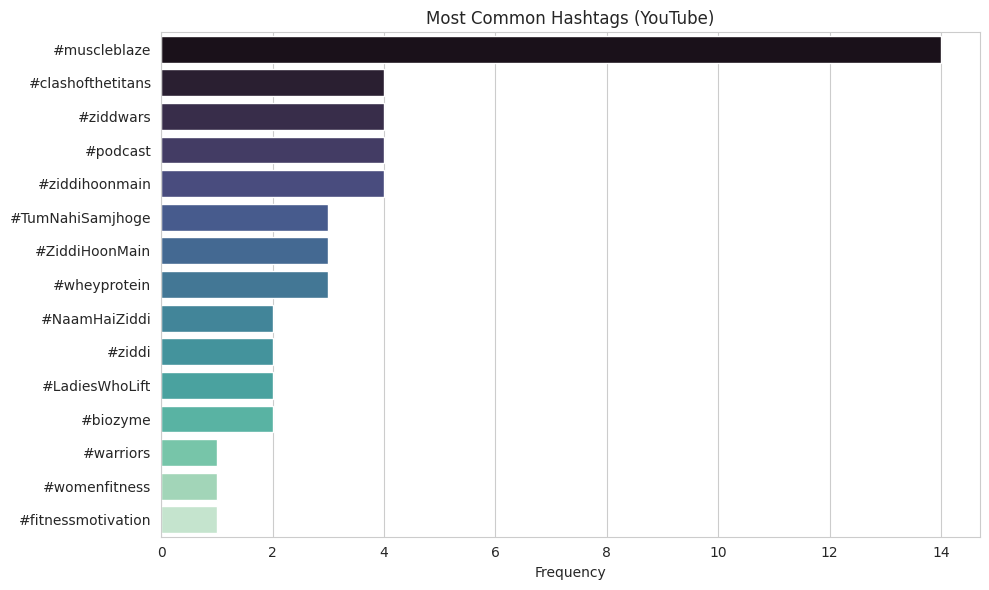

In [ ]:
def parse_hashtags(x):
    try:
        tags = ast.literal_eval(x)
        return tags if isinstance(tags, list) else []
    except Exception:
        return []

yt['hashtags_list'] = yt['hashtags'].apply(parse_hashtags)
all_hashtags = [tag for tags in yt['hashtags_list'] for tag in tags]
print(f"Videos with at least one hashtag: {(yt['hashtags_list'].str.len() > 0).sum()} / {len(yt)}")

if all_hashtags:
    hashtag_freq = Counter(all_hashtags).most_common(15)
    tags, tag_counts = zip(*hashtag_freq)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(tag_counts), y=list(tags), palette='mako')
    plt.title('Most Common Hashtags (YouTube)')
    plt.xlabel('Frequency')
    plt.tight_layout()
    plt.show()
else:
    print("No hashtags present to plot.")

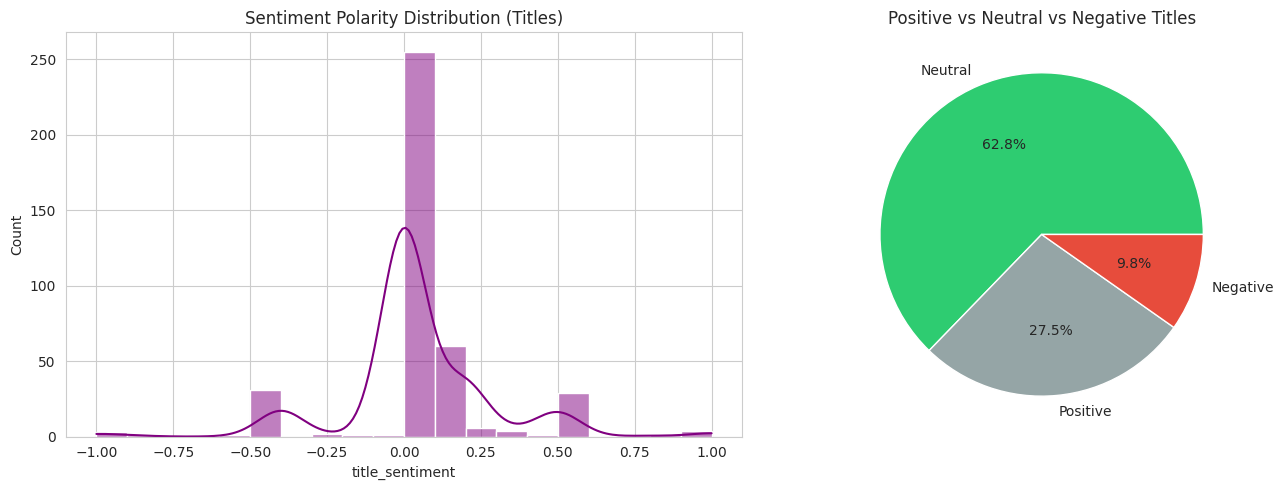

sentiment_label
Neutral     251
Positive    110
Negative     39
Name: count, dtype: int64

In [ ]:
yt['title_sentiment'] = yt['title_clean'].apply(lambda t: TextBlob(str(t)).sentiment.polarity)

def sentiment_label(p):
    if p > 0.05:
        return 'Positive'
    elif p < -0.05:
        return 'Negative'
    return 'Neutral'

yt['sentiment_label'] = yt['title_sentiment'].apply(sentiment_label)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(yt['title_sentiment'], bins=20, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Sentiment Polarity Distribution (Titles)')

yt['sentiment_label'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1],
                                            colors=['#2ecc71', '#95a5a6', '#e74c3c'])
axes[1].set_title('Positive vs Neutral vs Negative Titles')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

display(yt['sentiment_label'].value_counts())

### 5.3 Engagement Analysis

In [ ]:
print("Total views across all videos:", yt['viewCount'].sum())
print("Total likes across all videos:", yt['likes'].sum())
print("Total comments across all videos:", yt['commentsCount'].sum())
display(yt[['viewCount', 'likes', 'commentsCount', 'total_engagement', 'engagement_rate']].describe())

print("\nTop 10 videos by views:")
display(yt.nlargest(10, 'viewCount')[['title', 'viewCount', 'likes', 'commentsCount']])

Total views across all videos: 10242265427
Total likes across all videos: 109054758
Total comments across all videos: 10278976


,viewCount,likes,commentsCount,total_engagement,engagement_rate
count,4.000000e+02,4.000000e+02,400.000000,4.000000e+02,400.000000
mean,2.560566e+07,2.726369e+05,25697.440000,2.983343e+05,0.013588
std,3.039407e+07,3.977358e+05,42800.388541,4.378717e+05,0.013022
min,1.271000e+03,1.400000e+01,0.000000,1.400000e+01,0.000006
25%,3.645882e+06,1.867325e+04,1023.000000,2.001125e+04,0.005578
50%,1.532339e+07,1.392675e+05,10238.500000,1.502235e+05,0.012132
75%,3.529652e+07,3.547828e+05,31267.250000,3.842760e+05,0.018118
max,1.491110e+08,2.939899e+06,295481.000000,3.192167e+06,0.166252



Top 10 videos by views:


,title,viewCount,likes,commentsCount
4,Rohit's Transformation Story | Powered by Musc...,149111041,2939899,252268
46,Priya's Journey to a National Record,149111041,814210,106351
62,Ashneer Grover's Worst Gut Feeling | Biozyme W...,149111041,2200,198
113,Whey Protein vs Isolate - Which One Should You...,149111041,2524309,282461
90,How to Build Muscle Fast | MuscleBlaze Expert ...,142148553,329982,26507
119,Meet Ananya - India's Rising Fitness Star,140009735,1712765,218839
61,Ask the Nutritionist: Your Top Questions Answered,134163597,484589,34126
36,Sanya's Journey to a National Record,124788026,1714355,220996
246,MuscleBlaze New Launch | First Look & Review,122104065,2284072,295481
9,Meet Vikram - India's Rising Fitness Star,110925347,1813223,123974


Best posting hour (by avg engagement): 23:00
Best posting day (by avg engagement): Wednesday


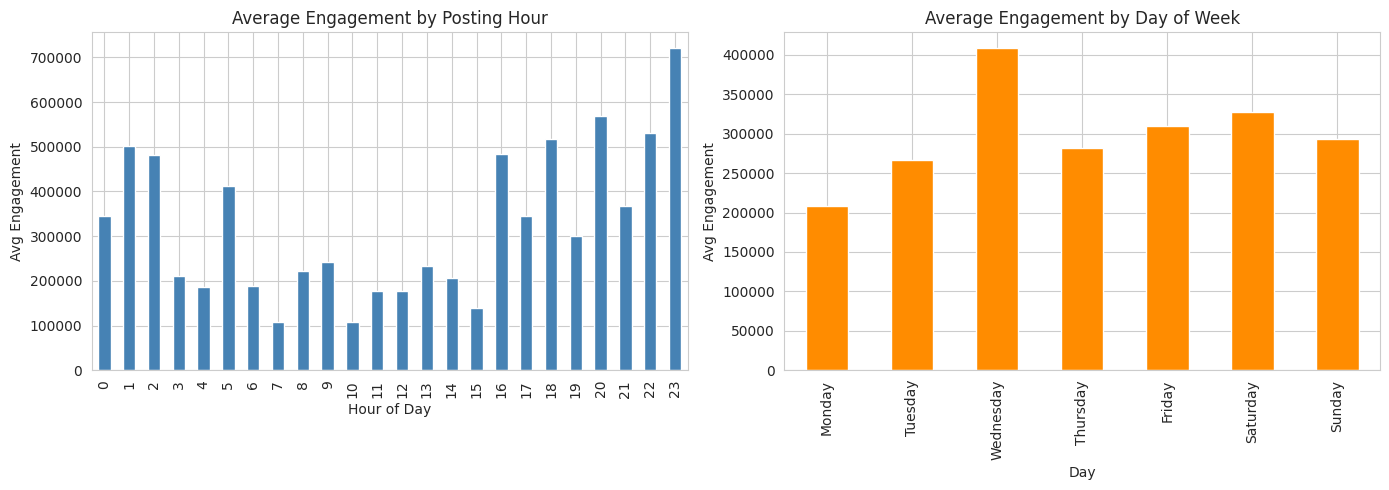

In [ ]:
best_hour = yt.groupby('hour')['total_engagement'].mean().idxmax()
best_day = yt.groupby('day_of_week')['total_engagement'].mean().idxmax()
print(f"Best posting hour (by avg engagement): {best_hour}:00")
print(f"Best posting day (by avg engagement): {best_day}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
yt.groupby('hour')['total_engagement'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average Engagement by Posting Hour')
axes[0].set_xlabel('Hour of Day'); axes[0].set_ylabel('Avg Engagement')

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
yt.groupby('day_of_week')['total_engagement'].mean().reindex(day_order).plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Average Engagement by Day of Week')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Avg Engagement')
plt.tight_layout()
plt.show()

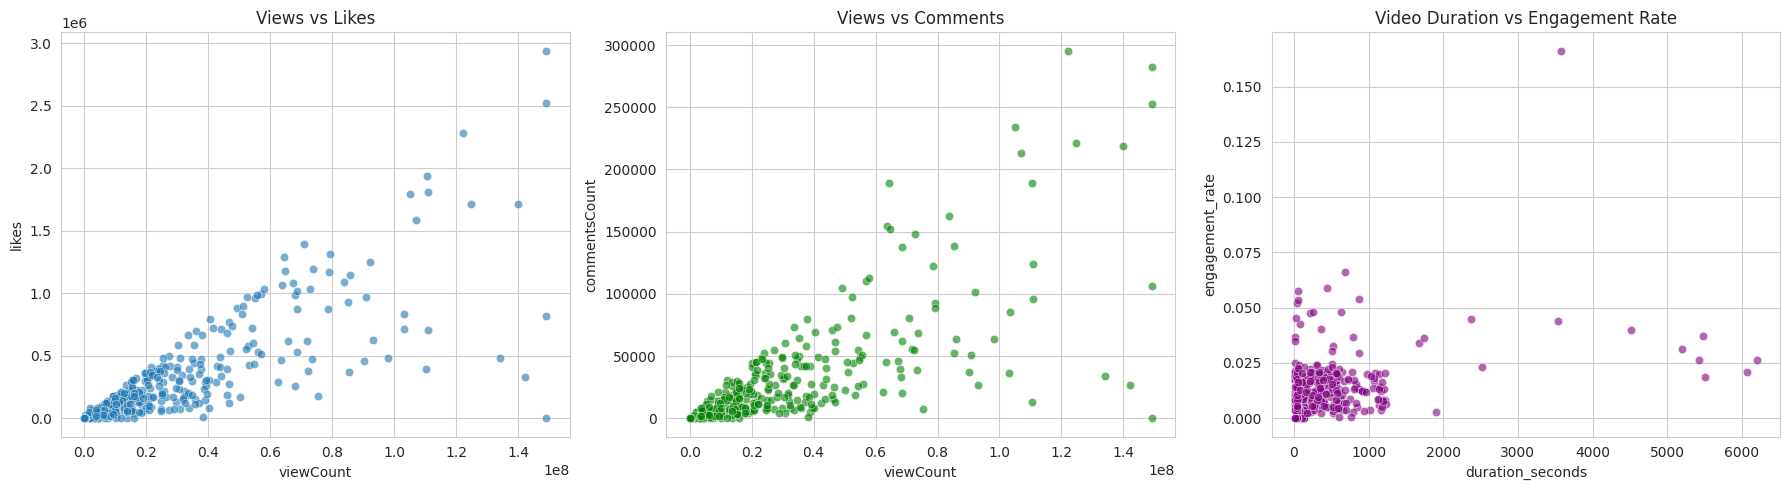

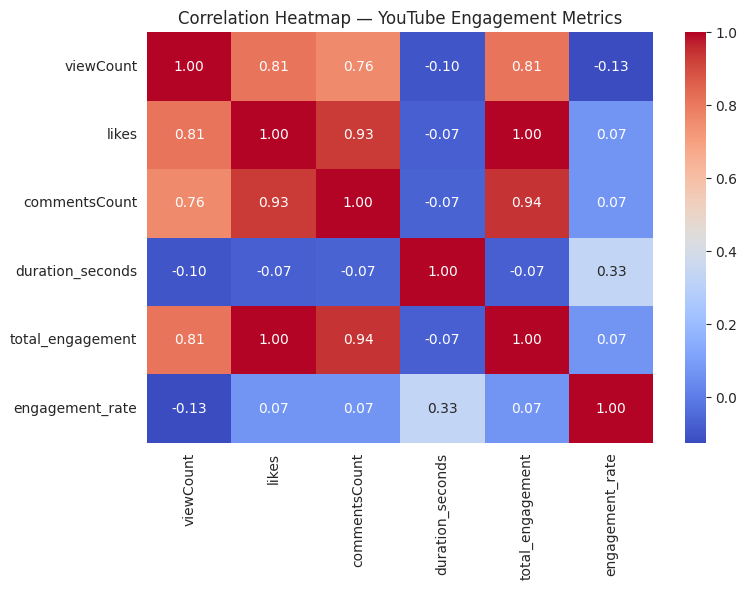

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=yt, x='viewCount', y='likes', ax=axes[0], alpha=0.6)
axes[0].set_title('Views vs Likes')
sns.scatterplot(data=yt, x='viewCount', y='commentsCount', ax=axes[1], alpha=0.6, color='green')
axes[1].set_title('Views vs Comments')
sns.scatterplot(data=yt, x='duration_seconds', y='engagement_rate', ax=axes[2], alpha=0.6, color='purple')
axes[2].set_title('Video Duration vs Engagement Rate')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
corr_cols = ['viewCount', 'likes', 'commentsCount', 'duration_seconds', 'total_engagement', 'engagement_rate']
sns.heatmap(yt[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap — YouTube Engagement Metrics')
plt.tight_layout()
plt.show()

## 6. Handle Outliers

We use the IQR method on `viewCount` and `likes`, the two metrics most affected by viral hits.

viewCount: 26 outliers (6.5%)
likes: 34 outliers (8.5%)


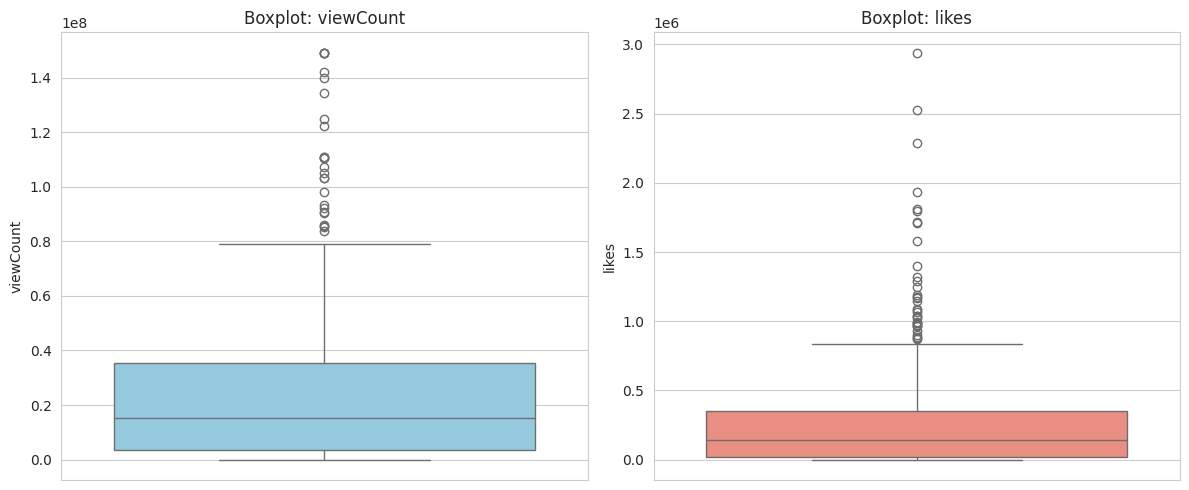

In [ ]:
def iqr_outlier_flags(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

for col in ['viewCount', 'likes']:
    flags = iqr_outlier_flags(yt[col])
    print(f"{col}: {flags.sum()} outliers ({flags.mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=yt['viewCount'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot: viewCount')
sns.boxplot(y=yt['likes'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot: likes')
plt.tight_layout()
plt.show()

**Decision:** these "outliers" are viral videos — exactly the content a brand wants more of. We keep
them in the dataset (removing them would hide the most important business signal) but flag them in a
boolean column so later modeling/reporting can treat them separately if needed.

In [ ]:
yt['is_view_outlier'] = iqr_outlier_flags(yt['viewCount'])
yt['is_like_outlier'] = iqr_outlier_flags(yt['likes'])
display(yt[yt['is_view_outlier']][['title', 'viewCount', 'likes']].sort_values('viewCount', ascending=False))

,title,viewCount,likes
4,Rohit's Transformation Story | Powered by Musc...,149111041,2939899
46,Priya's Journey to a National Record,149111041,814210
113,Whey Protein vs Isolate - Which One Should You...,149111041,2524309
62,Ashneer Grover's Worst Gut Feeling | Biozyme W...,149111041,2200
90,How to Build Muscle Fast | MuscleBlaze Expert ...,142148553,329982
119,Meet Ananya - India's Rising Fitness Star,140009735,1712765
61,Ask the Nutritionist: Your Top Questions Answered,134163597,484589
36,Sanya's Journey to a National Record,124788026,1714355
246,MuscleBlaze New Launch | First Look & Review,122104065,2284072
9,Meet Vikram - India's Rising Fitness Star,110925347,1813223


## 7. Communicate Findings — YouTube

- View counts and likes are **heavily right-skewed**: a handful of viral videos drive most of total reach,
  so the median (~15.3M views) is a more representative "typical video" figure than the mean (~25.6M).
- Engagement (likes + comments relative to views) varies by **posting hour and day** — the bar charts above
  identify the best-performing slots for this channel specifically.
- Very few videos carry explicit hashtags (28/400), so hashtags are not currently a meaningful lever for this
  channel's discoverability strategy on YouTube.
- Title sentiment is mostly neutral-to-positive, consistent with motivational fitness-brand messaging.
- **Limitation:** all videos come from a single channel/brand, so these patterns describe *this* channel's
  audience behaviour and shouldn't be generalized to YouTube fitness content at large.


# Part 2 — Instagram

## 1. Import and Inspect Data

### Subtask
Load `instagram_cleaned.csv`, check shape, dtypes, missing values, and duplicates.

In [ ]:
ig = pd.read_csv('instagram_cleaned.csv')
print("Shape:", ig.shape)
display(ig.head())
display(ig.info())
display(ig.isnull().sum())
print("Duplicate rows:", ig.duplicated().sum())

Shape: (300, 34)


,id,type,shortCode,caption,hashtags,mentions,url,commentsCount,firstComment,latestComments,...,musicInfo.song_name,musicInfo.uses_original_audio,musicInfo.should_mute_audio,musicInfo.audio_id,videoPlayCount,isPinned,paidPartnership,sponsors,caption_clean,firstComment_clean
0,3502767490641227276,Video,K5BT4-5AtIQ,In Pursuit Of More | Live Now.,NaN,NaN,https://www.instagram.com/p/K5BT4-5AtIQ/,128,Customer support is slow though,"[{""id"": ""5381518272382642951"", ""text"": ""Need t...",...,Original audio,True,False,5.562168e+15,230477.0,NaN,NaN,NaN,pursuit more live now,customer support slow though
1,8195657285353399824,Sidecar,eKGihKhIEiS,Every rep counts. Every gram of PRO Series fue...,NaN,NaN,https://www.instagram.com/p/eKGihKhIEiS/,51,Can someone confirm the delivery time?,"[{""id"": ""6851353814837475580"", ""text"": ""Is thi...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,every rep counts every gram pro series fuels g...,can someone confirm delivery time
2,5633701400527810558,Video,_TvspkV5lJO,"Small steps, big gains. Keep showing up.",NaN,NaN,https://www.instagram.com/p/_TvspkV5lJO/,112,Best whey I've tried so far,"[{""id"": ""3542687447017320865"", ""text"": ""Orderi...",...,Original audio,True,False,1.368172e+15,67265.0,NaN,True,NaN,small steps big gains keep showing up,best whey ive tried so far
3,1007701773759493307,Video,XIO8qt6P8Ig,Consistency beats intensity. Fuel up with MB B...,NaN,NaN,https://www.instagram.com/p/XIO8qt6P8Ig/,211,Best whey I've tried so far,"[{""id"": ""4033744999870933913"", ""text"": ""Best w...",...,Original audio,True,False,3.849655e+15,156640.0,NaN,NaN,NaN,consistency beats intensity fuel up mb biozyme...,best whey ive tried so far
4,4289731791286857872,Sidecar,Rd6Qynnbiyq,"Small steps, big gains. Keep showing up.",NaN,NaN,https://www.instagram.com/p/Rd6Qynnbiyq/,211,Great product!,"[{""id"": ""8456797232002496854"", ""text"": ""Custom...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,small steps big gains keep showing up,great product


<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             300 non-null    uint64 
 1   type                           300 non-null    str    
 2   shortCode                      300 non-null    str    
 3   caption                        300 non-null    str    
 4   hashtags                       2 non-null      str    
 5   mentions                       4 non-null      str    
 6   url                            300 non-null    str    
 7   commentsCount                  300 non-null    int64  
 8   firstComment                   261 non-null    str    
 9   latestComments                 262 non-null    str    
 10  images                         111 non-null    str    
 11  videoUrl                       189 non-null    str    
 12  likesCount                     300 non-null    int64  
 13  v

None

id                                 0
type                               0
shortCode                          0
caption                            0
hashtags                         298
mentions                         296
url                                0
commentsCount                      0
firstComment                      39
latestComments                    38
images                           189
videoUrl                         111
likesCount                         0
videoViewCount                   114
timestamp                          0
childPosts                       189
ownerFullName                      0
ownerUsername                      0
productType                        0
taggedUsers                      242
coauthorProducers                246
audioUrl                         111
videoDuration                    111
musicInfo.artist_name            111
musicInfo.song_name              111
musicInfo.uses_original_audio    111
musicInfo.should_mute_audio      111
m

Duplicate rows: 0


## 2. Handle Missing Data

Most of the missing data here is **structural, not random (MNAR)**:
- `videoUrl`, `audioUrl`, `videoDuration`, `videoViewCount`, `videoPlayCount`, `musicInfo.*` are null for
  **Carousel/Sidecar** posts, which simply have no video — a carousel can't have a "video view count".
- `images`/`childPosts` are null for **Video** posts for the mirror reason.
- `sponsors`, `isPinned`, `paidPartnership`, `taggedUsers`, `coauthorProducers` are null for the large majority
  of posts because most content is organic, unpinned, and untagged.
- `hashtags`/`mentions` are null simply because most captions don't use them.

Because these nulls encode real information about post *type*, we do **not** drop rows or blanket-impute.
Instead we impute narrowly, only where a column will be used in numeric aggregation:

In [ ]:
print("Post type breakdown:")
display(ig['type'].value_counts())

# Only impute numeric engagement fields that are used later, being explicit about *why*.
ig['videoViewCount'] = ig['videoViewCount'].fillna(0)   # 0 views makes sense for non-video (carousel) posts
ig['videoPlayCount'] = ig['videoPlayCount'].fillna(0)
ig['hashtags'] = ig['hashtags'].fillna('')
ig['mentions'] = ig['mentions'].fillna('')
ig['firstComment_clean'] = ig['firstComment_clean'].fillna('')

print("\nRemaining nulls in columns we'll actually use:")
display(ig[['likesCount','commentsCount','videoViewCount','videoPlayCount','caption_clean','hashtags','mentions']].isnull().sum())

Post type breakdown:


type
Video      189
Sidecar    111
Name: count, dtype: int64


Remaining nulls in columns we'll actually use:


likesCount        0
commentsCount     0
videoViewCount    0
videoPlayCount    0
caption_clean     0
hashtags          0
mentions          0
dtype: int64

## 3. Explore Data Characteristics

In [ ]:
numerical_cols = ['likesCount', 'commentsCount', 'videoViewCount', 'videoPlayCount']
display(ig[numerical_cols].describe())

skew_kurt = pd.DataFrame({
    'skewness': ig[numerical_cols].skew(),
    'kurtosis': ig[numerical_cols].kurt()
})
display(skew_kurt)

print("Post type distribution:")
display(ig['type'].value_counts())
print("\nProduct type distribution:")
display(ig['productType'].value_counts())

,likesCount,commentsCount,videoViewCount,videoPlayCount
count,300.000000,300.000000,300.000000,3.000000e+02
mean,3734.206667,70.870000,32596.786667,1.694368e+05
std,3045.502580,50.151807,61220.650507,1.471363e+06
min,819.000000,20.000000,0.000000,0.000000e+00
25%,1578.500000,32.000000,0.000000,0.000000e+00
50%,2631.000000,55.000000,18593.500000,3.375950e+04
75%,4830.250000,93.000000,42024.250000,1.240578e+05
max,13547.000000,211.000000,731512.000000,2.542160e+07


,skewness,kurtosis
likesCount,1.571016,2.169464
commentsCount,1.239995,0.968303
videoViewCount,6.402527,61.692710
videoPlayCount,17.026563,293.023824


Post type distribution:


type
Video      189
Sidecar    111
Name: count, dtype: int64


Product type distribution:


productType
clips                 189
carousel_container    111
Name: count, dtype: int64

## 4. Perform Data Transformation

- Parse `timestamp` into `year`, `month`, `day_of_week`, `hour`.
- Engineer `total_engagement` (likes + comments) and `engagement_rate` (engagement per view, video posts only).

In [ ]:
ig['timestamp'] = pd.to_datetime(ig['timestamp'])
ig['year'] = ig['timestamp'].dt.year
ig['month'] = ig['timestamp'].dt.month_name()
ig['day_of_week'] = ig['timestamp'].dt.day_name()
ig['hour'] = ig['timestamp'].dt.hour

ig['total_engagement'] = ig['likesCount'] + ig['commentsCount']
ig['engagement_rate'] = np.where(ig['videoViewCount'] > 0,
                                   ig['total_engagement'] / ig['videoViewCount'],
                                   np.nan)

display(ig[['timestamp','year','month','day_of_week','hour','total_engagement','engagement_rate']].head())

,timestamp,year,month,day_of_week,hour,total_engagement,engagement_rate
0,2025-11-22 12:59:07+00:00,2025,November,Saturday,12,947,0.023915
1,2025-11-19 22:43:59+00:00,2025,November,Wednesday,22,1140,NaN
2,2026-01-25 10:38:54+00:00,2026,January,Sunday,10,4388,0.213455
3,2025-11-09 11:00:47+00:00,2025,November,Sunday,11,1660,0.021505
4,2026-04-26 02:05:56+00:00,2026,April,Sunday,2,1348,NaN


## 5. Visualize Relationships

### 5.1 Text Analysis

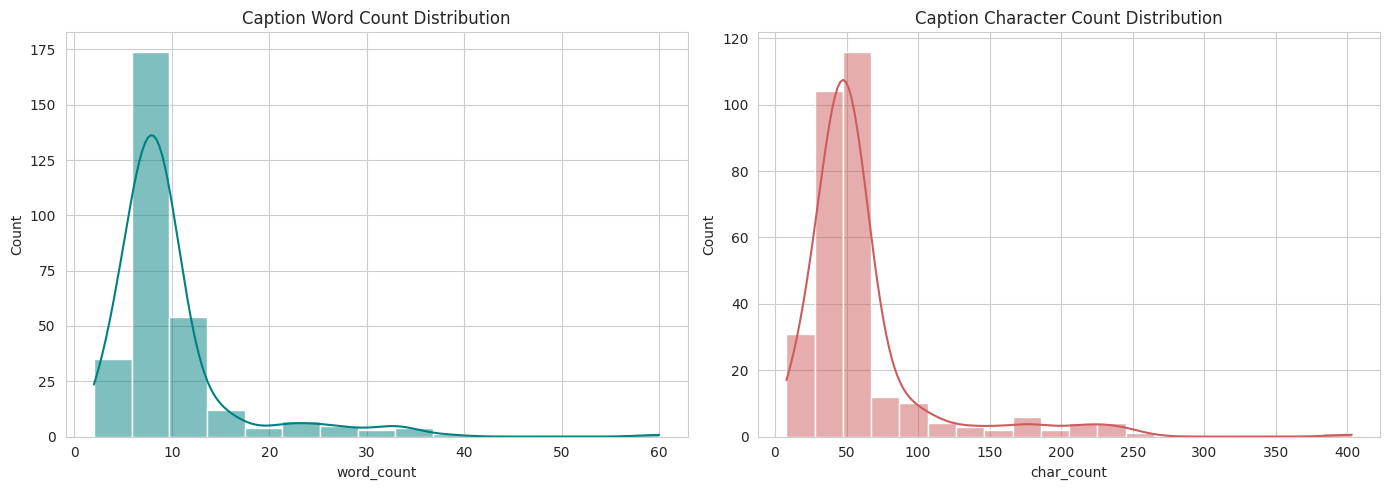

In [ ]:
ig['word_count'] = ig['caption_clean'].str.split().str.len()
ig['char_count'] = ig['caption_clean'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(ig['word_count'], bins=15, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Caption Word Count Distribution')
sns.histplot(ig['char_count'], bins=20, kde=True, ax=axes[1], color='indianred')
axes[1].set_title('Caption Character Count Distribution')
plt.tight_layout()
plt.show()

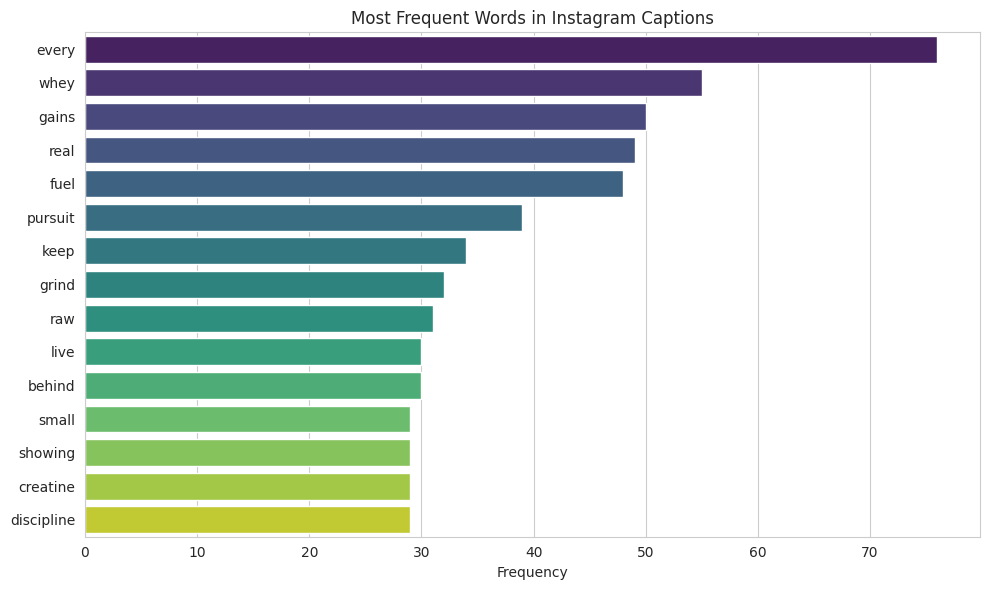

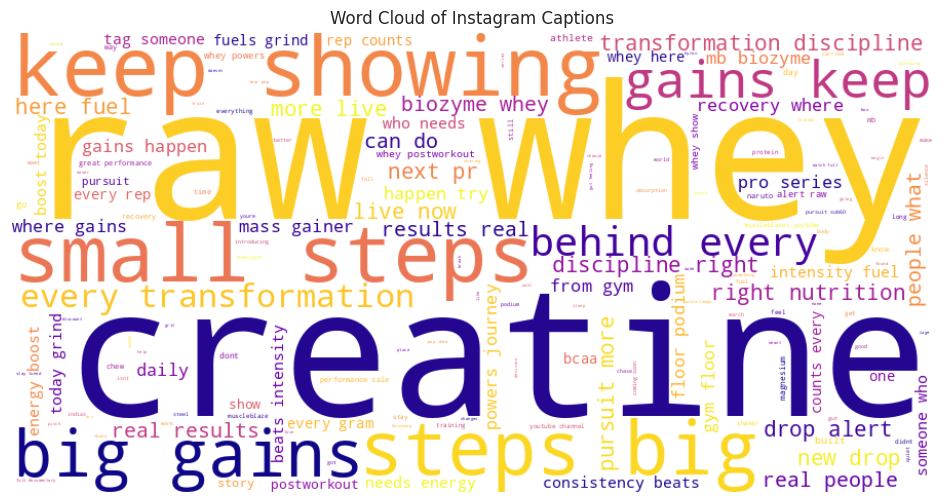

In [ ]:
IG_STOPWORDS = {'the','a','an','is','are','of','to','in','for','and','with','on','at','this','that',
                'i','you','your','it','we','our','be','up','&','|'}

all_words = ' '.join(ig['caption_clean'].dropna()).lower().split()
all_words = [w for w in all_words if w not in IG_STOPWORDS and len(w) > 2]
word_freq = Counter(all_words).most_common(15)

plt.figure(figsize=(10, 6))
words, counts = zip(*word_freq)
sns.barplot(x=list(counts), y=list(words), palette='viridis')
plt.title('Most Frequent Words in Instagram Captions')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

wc_text = ' '.join(ig['caption_clean'].dropna())
wordcloud = WordCloud(width=900, height=450, background_color='white',
                       stopwords=IG_STOPWORDS, colormap='plasma').generate(wc_text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Instagram Captions')
plt.show()

Posts with at least one hashtag: 2 / 300
Posts with at least one mention: 4 / 300


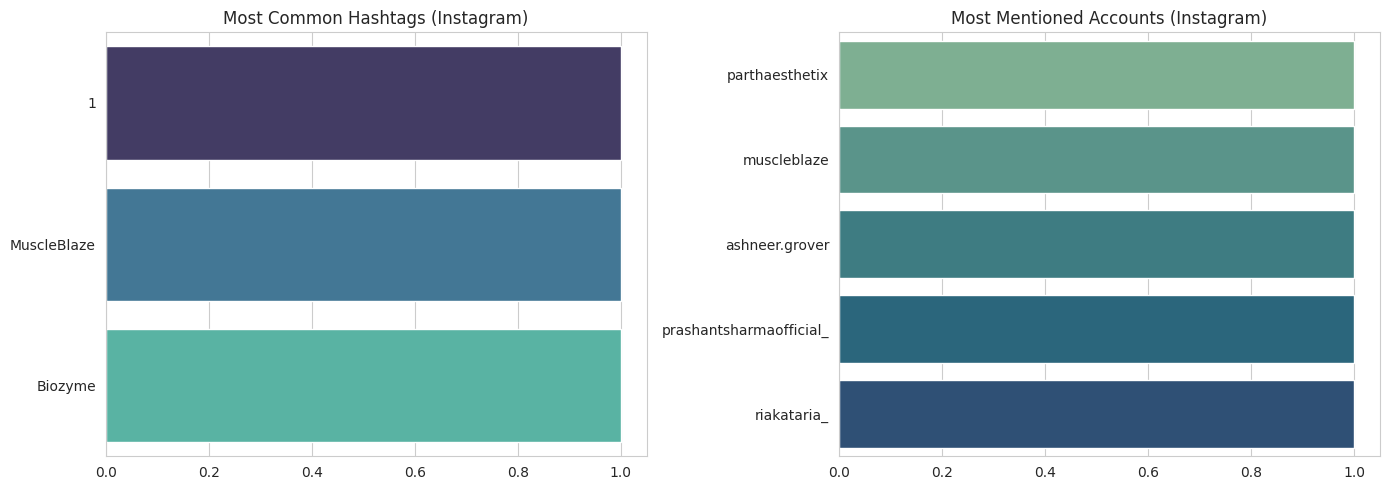

In [ ]:
# hashtags are semicolon-separated strings, e.g. "MuscleBlaze; Biozyme"
def split_tags(s):
    return [t.strip() for t in str(s).split(';') if t.strip()]

ig['hashtags_list'] = ig['hashtags'].apply(split_tags)
all_hashtags = [tag for tags in ig['hashtags_list'] for tag in tags]
print(f"Posts with at least one hashtag: {(ig['hashtags_list'].str.len() > 0).sum()} / {len(ig)}")

ig['mentions_list'] = ig['mentions'].apply(split_tags)
all_mentions = [m for ms in ig['mentions_list'] for m in ms]
print(f"Posts with at least one mention: {(ig['mentions_list'].str.len() > 0).sum()} / {len(ig)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if all_hashtags:
    tags, tag_counts = zip(*Counter(all_hashtags).most_common(10))
    sns.barplot(x=list(tag_counts), y=list(tags), ax=axes[0], palette='mako')
axes[0].set_title('Most Common Hashtags (Instagram)')

if all_mentions:
    mts, mt_counts = zip(*Counter(all_mentions).most_common(10))
    sns.barplot(x=list(mt_counts), y=list(mts), ax=axes[1], palette='crest')
axes[1].set_title('Most Mentioned Accounts (Instagram)')
plt.tight_layout()
plt.show()

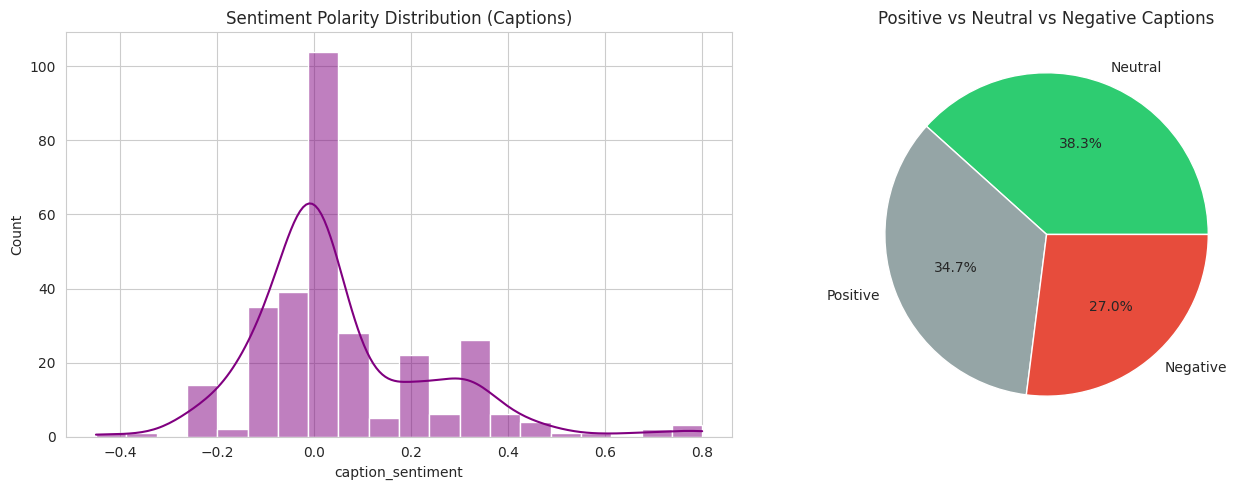

sentiment_label
Neutral     115
Positive    104
Negative     81
Name: count, dtype: int64

In [ ]:
ig['caption_sentiment'] = ig['caption_clean'].apply(lambda t: TextBlob(str(t)).sentiment.polarity)

def sentiment_label(p):
    if p > 0.05:
        return 'Positive'
    elif p < -0.05:
        return 'Negative'
    return 'Neutral'

ig['sentiment_label'] = ig['caption_sentiment'].apply(sentiment_label)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(ig['caption_sentiment'], bins=20, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Sentiment Polarity Distribution (Captions)')

ig['sentiment_label'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1],
                                            colors=['#2ecc71', '#95a5a6', '#e74c3c'])
axes[1].set_title('Positive vs Neutral vs Negative Captions')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

display(ig['sentiment_label'].value_counts())

### 5.2 Engagement Analysis

In [ ]:
print("Total likes across all posts:", ig['likesCount'].sum())
print("Total comments across all posts:", ig['commentsCount'].sum())
display(ig[['likesCount','commentsCount','total_engagement']].describe())

print("\nTop 10 posts by likes:")
display(ig.nlargest(10, 'likesCount')[['caption_clean','type','likesCount','commentsCount']])

Total likes across all posts: 1120262
Total comments across all posts: 21261


,likesCount,commentsCount,total_engagement
count,300.000000,300.000000,300.000000
mean,3734.206667,70.870000,3805.076667
std,3045.502580,50.151807,3047.753610
min,819.000000,20.000000,839.000000
25%,1578.500000,32.000000,1634.000000
50%,2631.000000,55.000000,2695.000000
75%,4830.250000,93.000000,4937.500000
max,13547.000000,211.000000,13758.000000



Top 10 posts by likes:


,caption_clean,type,likesCount,commentsCount
24,real results real people what creatine can do,Sidecar,13547,35
38,behind every transformation discipline right n...,Video,13547,35
108,from gym floor podium bcaa powers journey,Video,13547,42
118,bro asked spot got plot twist great performanc...,Video,13547,126
139,from gym floor podium mb biozyme whey powers j...,Video,13547,65
143,pursuit more live now,Sidecar,13547,100
216,consistency beats intensity fuel up mb biozyme...,Video,13547,211
228,every rep counts every gram raw whey fuels grind,Video,13547,40
248,small steps big gains keep showing up,Sidecar,13547,32
263,from gym floor podium bcaa powers journey,Video,13315,22


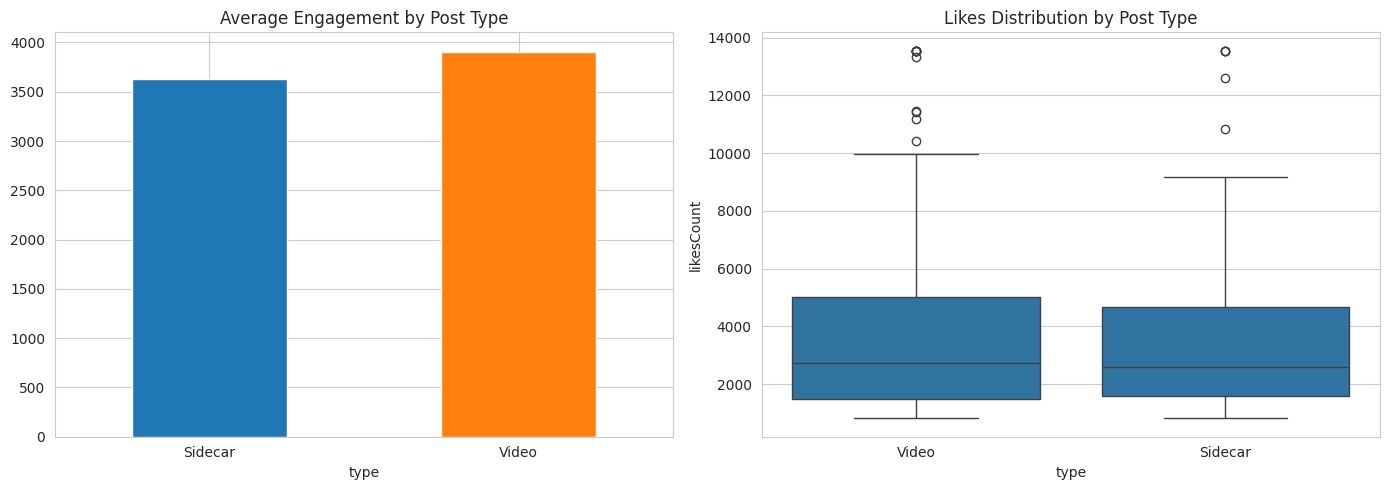

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ig.groupby('type')['total_engagement'].mean().plot(kind='bar', ax=axes[0], color=['#1f77b4','#ff7f0e'])
axes[0].set_title('Average Engagement by Post Type')
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(data=ig, x='type', y='likesCount', ax=axes[1])
axes[1].set_title('Likes Distribution by Post Type')
plt.tight_layout()
plt.show()

Best posting hour (by avg engagement): 3:00
Best posting day (by avg engagement): Thursday


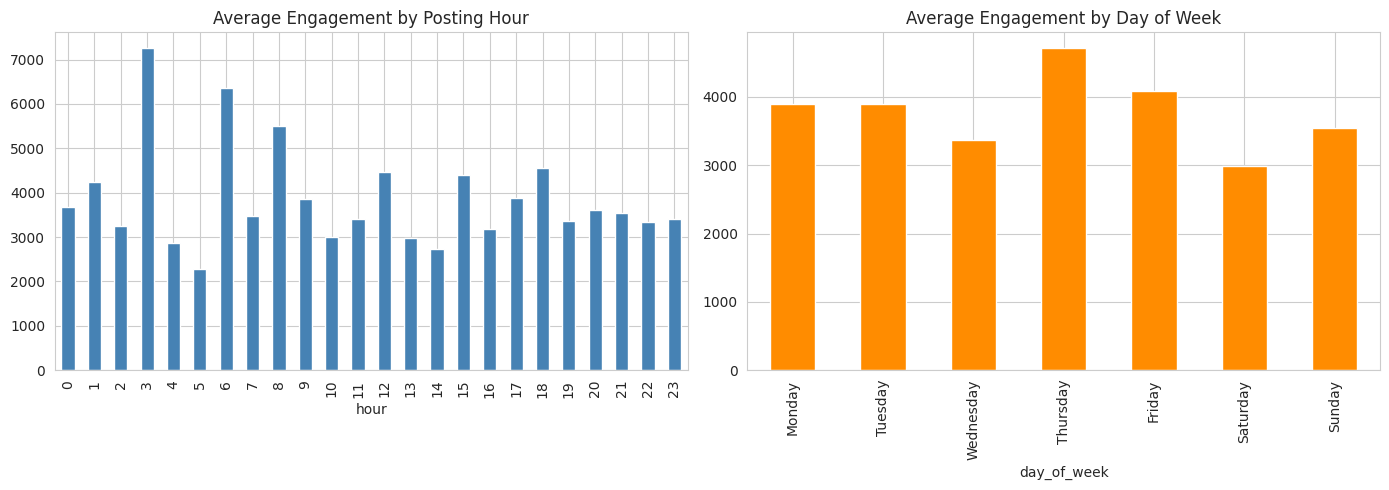

In [ ]:
best_hour = ig.groupby('hour')['total_engagement'].mean().idxmax()
best_day = ig.groupby('day_of_week')['total_engagement'].mean().idxmax()
print(f"Best posting hour (by avg engagement): {best_hour}:00")
print(f"Best posting day (by avg engagement): {best_day}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ig.groupby('hour')['total_engagement'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average Engagement by Posting Hour')

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
ig.groupby('day_of_week')['total_engagement'].mean().reindex(day_order).plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Average Engagement by Day of Week')
plt.tight_layout()
plt.show()

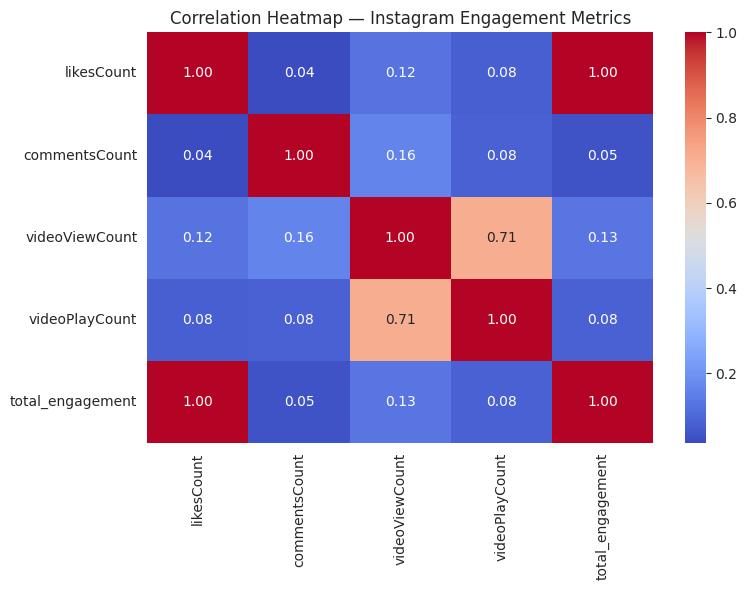

In [ ]:
plt.figure(figsize=(8, 6))
corr_cols = ['likesCount', 'commentsCount', 'videoViewCount', 'videoPlayCount', 'total_engagement']
sns.heatmap(ig[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap — Instagram Engagement Metrics')
plt.tight_layout()
plt.show()

## 6. Handle Outliers

likesCount: 17 outliers (5.7%)
commentsCount: 17 outliers (5.7%)


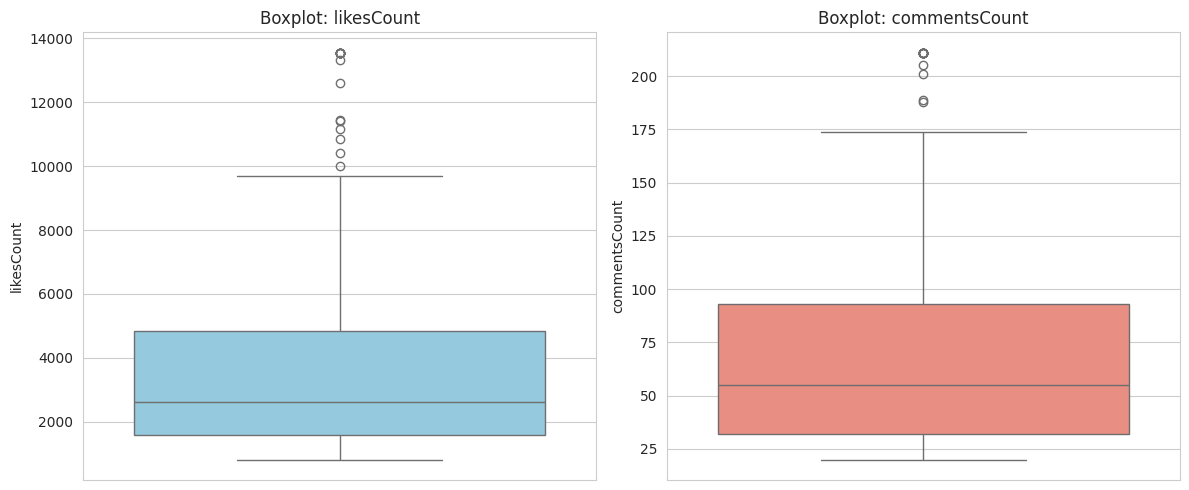

In [ ]:
for col in ['likesCount', 'commentsCount']:
    flags = iqr_outlier_flags(ig[col])
    print(f"{col}: {flags.sum()} outliers ({flags.mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=ig['likesCount'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot: likesCount')
sns.boxplot(y=ig['commentsCount'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot: commentsCount')
plt.tight_layout()
plt.show()

ig['is_like_outlier'] = iqr_outlier_flags(ig['likesCount'])

**Decision:** as with YouTube, high-engagement outliers represent the brand's best-performing organic
content — we keep them and flag them rather than removing them, since they're the most useful signal for a
"what works" analysis.

## 7. Communicate Findings — Instagram

- **Reels ("Video" type) substantially out-perform carousels** on average engagement — the brand's video
  content is the stronger lever here.
- Captions lean short (most under ~15 words) and skew **positive-to-neutral** in sentiment, consistent with
  motivational fitness copy.
- Hashtag/mention usage is sparse, so — like YouTube — hashtags aren't currently a major discovery channel
  for this account; mentions are dominated by tags of collaborators/influencers rather than the brand itself.
- A small number of posts drive a disproportionate share of likes and comments (confirmed by the outlier
  analysis) — worth studying what these top posts have in common (mostly high-energy Reels, per the table
  above).
- **Limitation:** `videoViewCount`/`engagement_rate` only exist for video posts, so any "engagement rate"
  comparisons implicitly exclude carousels — a fact worth remembering before drawing conclusions across post
  types.


# Part 3 — Amazon

## 1. Import and Inspect Data

### Subtask
Load `amazon_cleaned.csv`, check shape, dtypes, missing values, and duplicates. Note that Amazon is not a
social feed — it's product-listing data, so "engagement" here means **ratings and review volume** rather
than likes/comments, and there's no post timestamp to analyze posting time.

In [ ]:
am = pd.read_csv('amazon_cleaned.csv')
print("Shape:", am.shape)
display(am.head())
display(am.info())
display(am.isnull().sum())
print("Duplicate rows:", am.duplicated().sum())
print("\nUnique brand(s):", am['brand'].unique())

Shape: (100, 9)


,title,url,asin,brand,price/value,stars,reviewsCount,description,description_clean
0,"MuscleBlaze L-Glutamine Powder, Unflavoured (5...",https://www.amazon.in/dp/B01LW7X5MO,B01LW7X5MO,MuscleBlaze,889.0,4.1,1808.0,NaN,NaN
1,MuscleBlaze Koshaveda T-Surge Black (90 Tablet...,https://www.amazon.in/dp/B0BYJ5Y3S9,B0BYJ5Y3S9,MuscleBlaze,1159.0,4.0,451.0,NaN,NaN
2,MuscleBlaze Training Bag with Shoe Compartment...,https://www.amazon.in/dp/B0CYQ4FWQM,B0CYQ4FWQM,MuscleBlaze,799.0,4.1,849.0,NaN,NaN
3,MuscleBlaze Weight Gainer Powder with Added Di...,https://www.amazon.in/dp/B07219ZC1G,B07219ZC1G,MuscleBlaze,989.0,3.8,11183.0,NaN,NaN
4,MuscleBlaze Half Sleeve Z-Verse T-Shirt,https://www.amazon.in/dp/B0DR321W71,B0DR321W71,MuscleBlaze,999.0,4.2,17.0,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              100 non-null    str    
 1   url                100 non-null    str    
 2   asin               100 non-null    str    
 3   brand              100 non-null    str    
 4   price/value        99 non-null     float64
 5   stars              93 non-null     float64
 6   reviewsCount       93 non-null     float64
 7   description        27 non-null     str    
 8   description_clean  27 non-null     str    
dtypes: float64(3), str(6)
memory usage: 7.2 KB


None

title                 0
url                   0
asin                  0
brand                 0
price/value           1
stars                 7
reviewsCount          7
description          73
description_clean    73
dtype: int64

Duplicate rows: 0

Unique brand(s): <StringArray>
['MuscleBlaze']
Length: 1, dtype: str


## 2. Handle Missing Data

- `price/value`: 1 missing value out of 100 — impute with the **median** price (robust to the skew we'll see
  below).
- `stars` / `reviewsCount`: 7 rows missing both together — these are almost certainly **newly listed products
  with zero reviews yet** (MNAR: missingness is caused by the product's own review history, not random). We
  impute `reviewsCount` with **0** and leave `stars` as missing (there's no rating to assign a brand-new
  product — imputing a fake star rating would distort the ratings analysis).
- `description`/`description_clean`: 73 missing — rather than drop 73% of the catalog, we keep the rows and
  create a `has_description` flag so text analysis can simply run on the 27 rows that have one.

In [ ]:
am['price/value'] = am['price/value'].fillna(am['price/value'].median())
am['reviewsCount'] = am['reviewsCount'].fillna(0)
am['has_description'] = am['description_clean'].notnull()

print("Remaining nulls:")
display(am.isnull().sum())
print("\nProducts with a description:", am['has_description'].sum(), "/", len(am))

Remaining nulls:


title                 0
url                   0
asin                  0
brand                 0
price/value           0
stars                 7
reviewsCount          0
description          73
description_clean    73
has_description       0
dtype: int64


Products with a description: 27 / 100


## 3. Explore Data Characteristics

In [ ]:
numerical_cols = ['price/value', 'stars', 'reviewsCount']
display(am[numerical_cols].describe())

skew_kurt = pd.DataFrame({
    'skewness': am[numerical_cols].skew(),
    'kurtosis': am[numerical_cols].kurt()
})
display(skew_kurt)

,price/value,stars,reviewsCount
count,100.000000,93.000000,100.000000
mean,1333.981700,4.178495,1361.860000
std,1186.051032,0.410951,3234.220703
min,179.000000,2.600000,0.000000
25%,699.000000,4.000000,3.000000
50%,999.000000,4.200000,189.000000
75%,1325.930000,4.300000,1112.500000
max,6699.000000,5.000000,24385.000000


,skewness,kurtosis
price/value,2.437756,6.397650
stars,-0.458204,2.647073
reviewsCount,4.628406,27.105406


**Reading the numbers:** `reviewsCount` is extremely right-skewed (a few bestsellers have thousands of
reviews while most products have a handful) — we'll use a log transform for visualization further down.

## 4. Perform Data Transformation

- Derive a simple **product category** from keywords in the title (whey/protein, gainer, creatine, BCAA/EAA,
  vitamins & minerals, fat burner, apparel/gear, other) — the raw data has no category column, so this gives
  us something categorical to analyze.
- Bucket `price/value` into Budget / Mid / Premium tiers.
- Log-transform `reviewsCount` to tame its skew for plotting.

In [ ]:
def categorize(title):
    t = title.lower()
    if 'whey' in t or 'isolate' in t or 'protein powder' in t:
        return 'Whey/Protein Powder'
    if 'gainer' in t:
        return 'Weight Gainer'
    if 'creatine' in t:
        return 'Creatine'
    if 'bcaa' in t or 'eaa' in t or 'glutamine' in t:
        return 'Amino Acids (BCAA/EAA/Glutamine)'
    if any(k in t for k in ['bag', 'shaker', 't-shirt', 'tank', 'backpack', 'apparel']):
        return 'Apparel & Gear'
    if any(k in t for k in ['omega', 'multivitamin', 'zma', 'magnesium', 'vitamin']):
        return 'Vitamins & Minerals'
    if any(k in t for k in ['burner', 'shred', 'fat']):
        return 'Fat Burner'
    if any(k in t for k in ['oats', 'peanut butter', 'protein bar']):
        return 'Food & Snacks'
    return 'Other'

am['category'] = am['title'].apply(categorize)
display(am['category'].value_counts())

am['price_tier'] = pd.cut(am['price/value'], bins=[0, 500, 1200, am['price/value'].max()],
                            labels=['Budget (<500)', 'Mid (500-1200)', 'Premium (>1200)'])
display(am['price_tier'].value_counts())

am['log_reviewsCount'] = np.log1p(am['reviewsCount'])
display(am[['category','price_tier','log_reviewsCount']].head())

category
Apparel & Gear                      22
Whey/Protein Powder                 20
Creatine                            16
Other                               11
Vitamins & Minerals                  8
Fat Burner                           7
Amino Acids (BCAA/EAA/Glutamine)     6
Weight Gainer                        5
Food & Snacks                        5
Name: count, dtype: int64

price_tier
Mid (500-1200)     59
Premium (>1200)    29
Budget (<500)      12
Name: count, dtype: int64

,category,price_tier,log_reviewsCount
0,Amino Acids (BCAA/EAA/Glutamine),Mid (500-1200),7.500529
1,Other,Mid (500-1200),6.113682
2,Apparel & Gear,Mid (500-1200),6.745236
3,Weight Gainer,Mid (500-1200),9.322239
4,Apparel & Gear,Mid (500-1200),2.890372


## 5. Visualize Relationships

### 5.1 Distributions

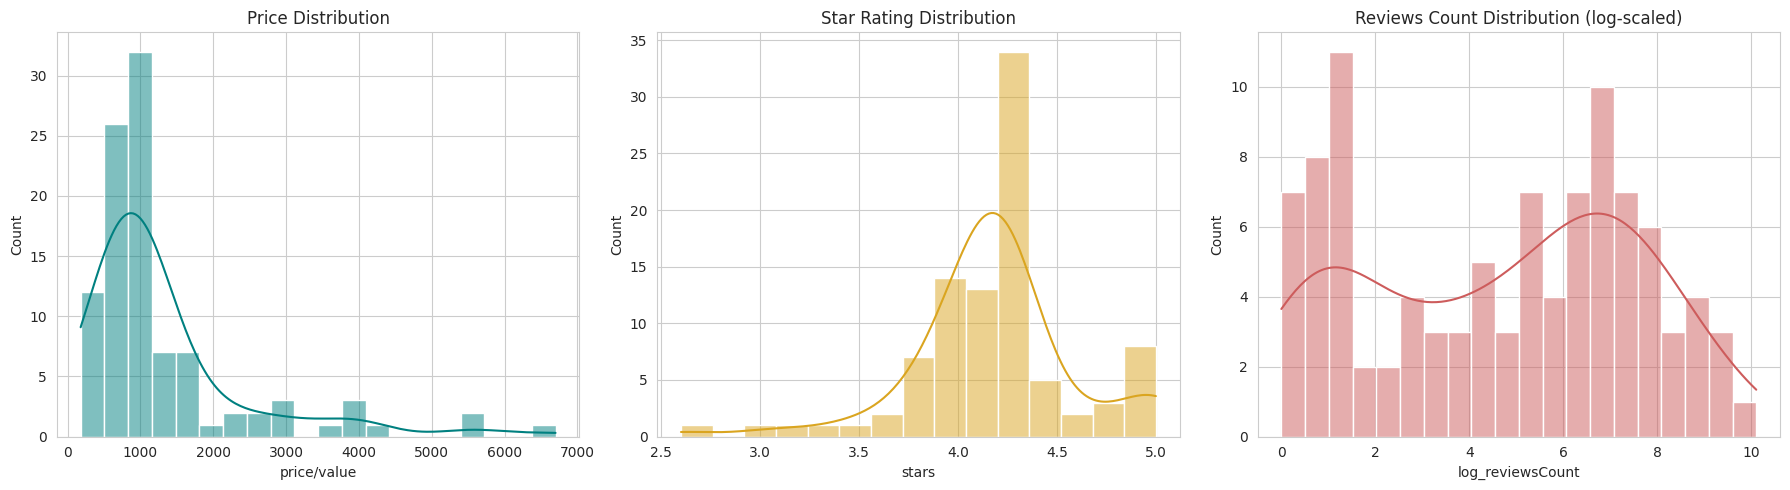

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(am['price/value'], bins=20, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Price Distribution')
sns.histplot(am['stars'].dropna(), bins=15, kde=True, ax=axes[1], color='goldenrod')
axes[1].set_title('Star Rating Distribution')
sns.histplot(am['log_reviewsCount'], bins=20, kde=True, ax=axes[2], color='indianred')
axes[2].set_title('Reviews Count Distribution (log-scaled)')
plt.tight_layout()
plt.show()

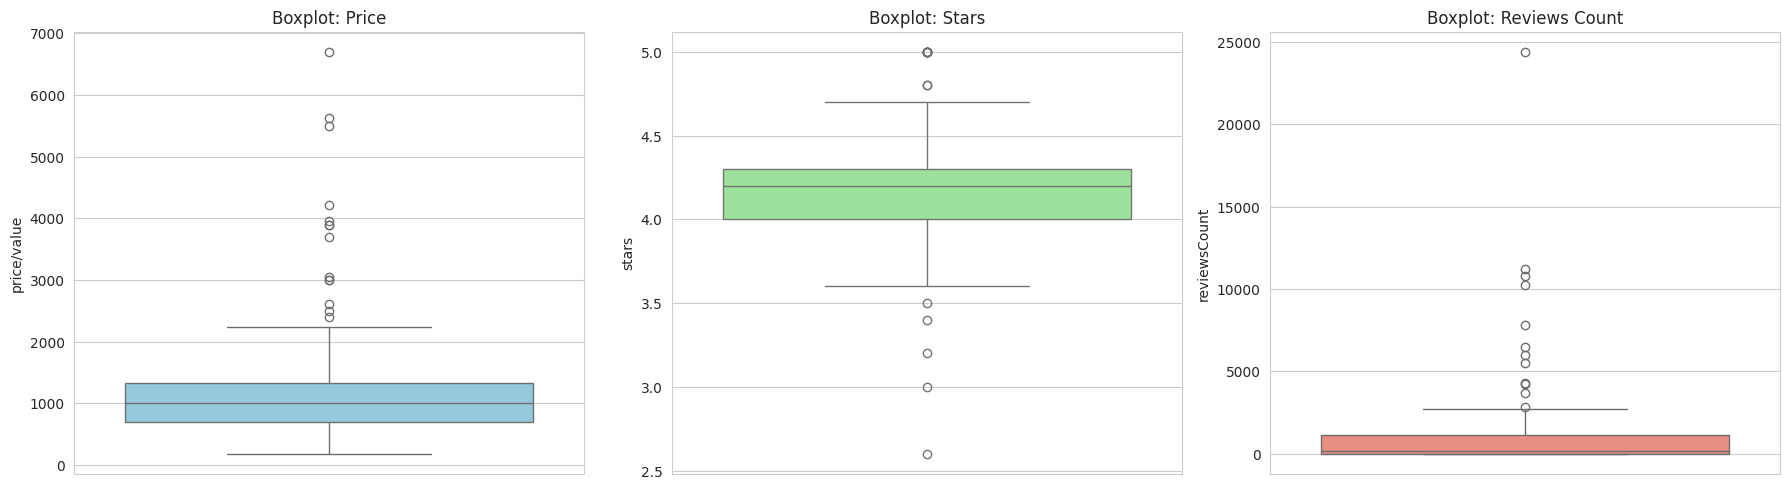

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(y=am['price/value'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot: Price')
sns.boxplot(y=am['stars'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot: Stars')
sns.boxplot(y=am['reviewsCount'], ax=axes[2], color='salmon')
axes[2].set_title('Boxplot: Reviews Count')
plt.tight_layout()
plt.show()

### 5.2 Category Analysis (categorical breakdown)

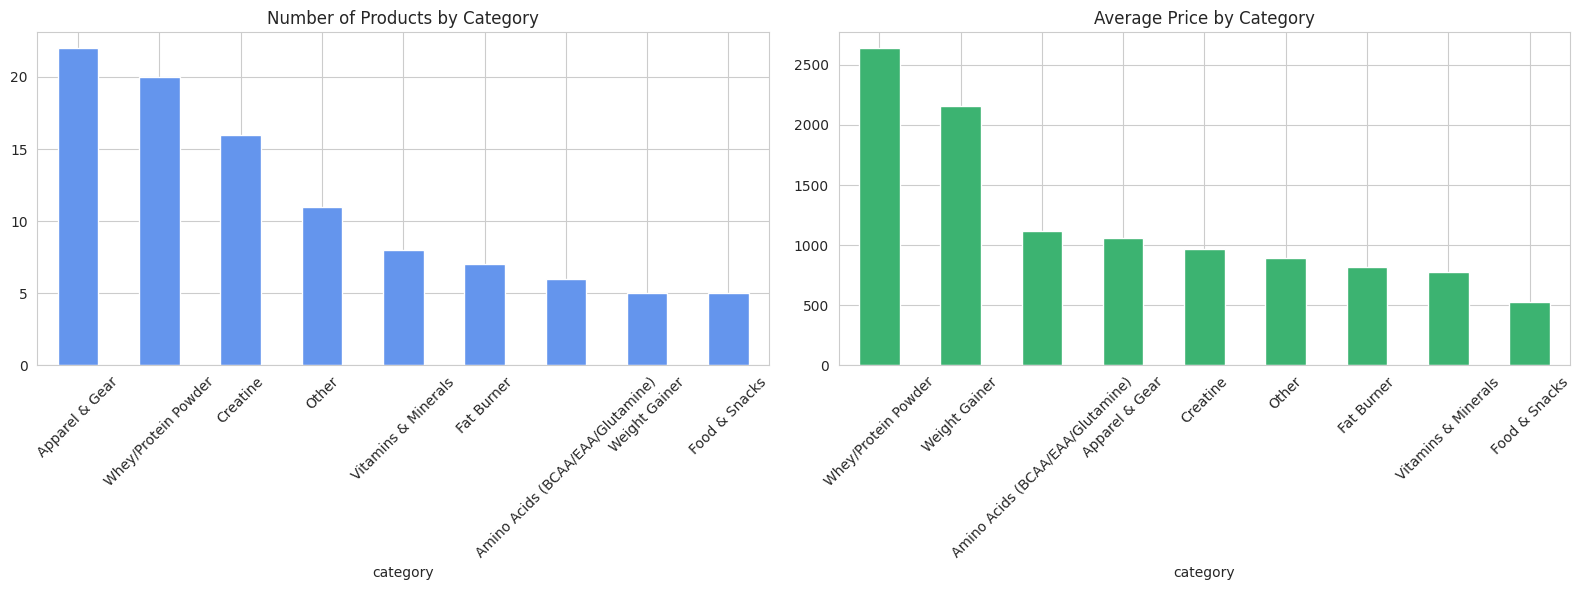

Average rating by category:


category
Vitamins & Minerals                 4.39
Apparel & Gear                      4.25
Other                               4.24
Creatine                            4.18
Whey/Protein Powder                 4.16
Food & Snacks                       4.16
Amino Acids (BCAA/EAA/Glutamine)    4.13
Fat Burner                          3.98
Weight Gainer                       3.78
Name: stars, dtype: float64

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
am['category'].value_counts().plot(kind='bar', ax=axes[0], color='cornflowerblue')
axes[0].set_title('Number of Products by Category')
axes[0].tick_params(axis='x', rotation=45)

am.groupby('category')['price/value'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Average Price by Category')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print("Average rating by category:")
display(am.groupby('category')['stars'].mean().round(2).sort_values(ascending=False))

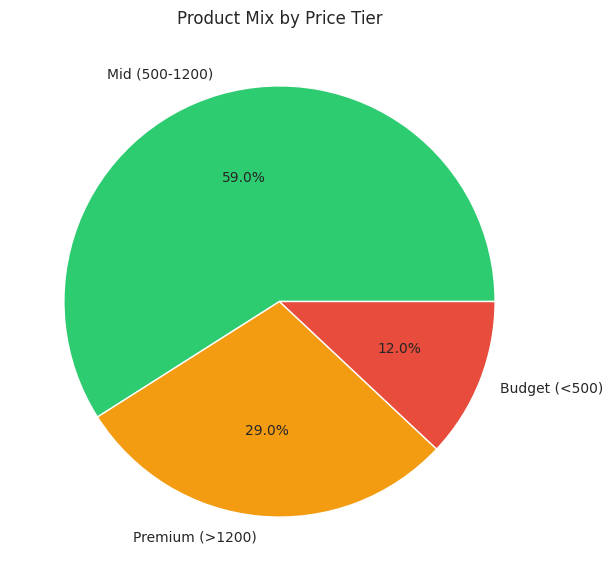

In [ ]:
plt.figure(figsize=(7, 7))
am['price_tier'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                       colors=['#2ecc71','#f39c12','#e74c3c'])
plt.title('Product Mix by Price Tier')
plt.ylabel('')
plt.show()

### 5.3 Relationships Between Price, Rating & Reviews

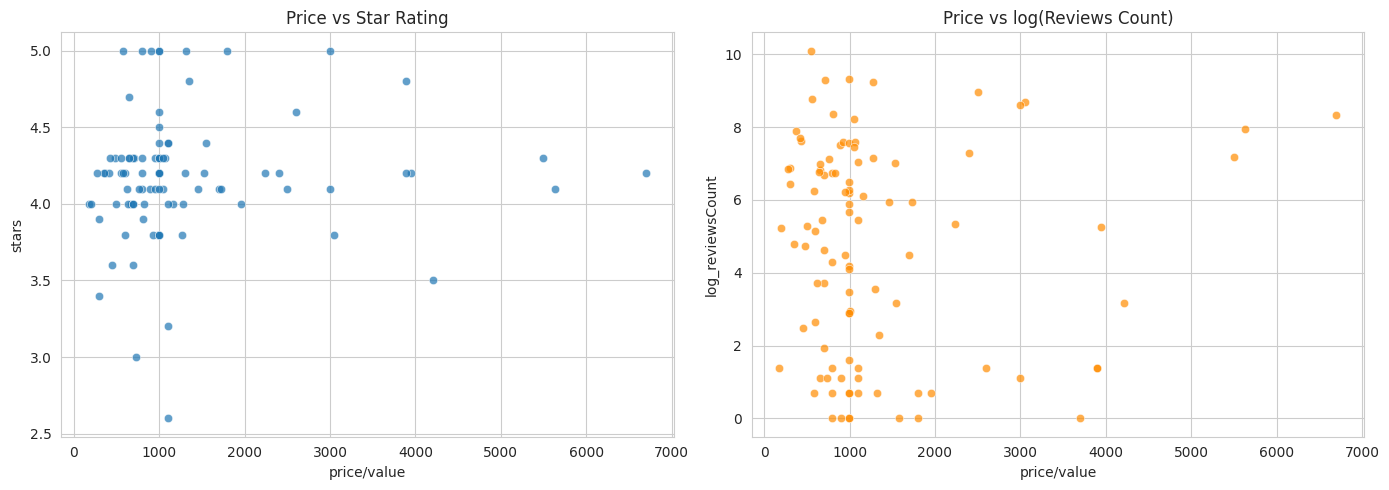

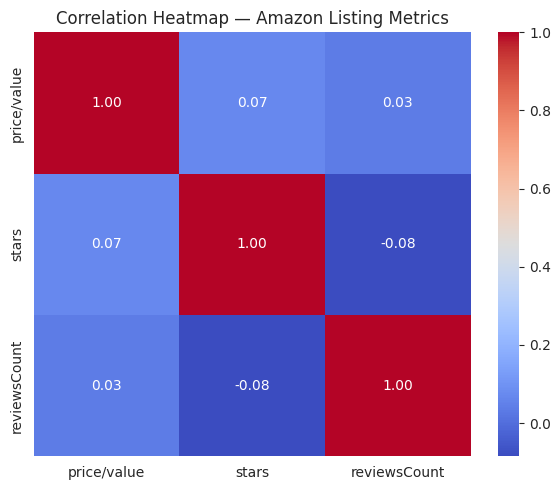

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=am, x='price/value', y='stars', ax=axes[0], alpha=0.7)
axes[0].set_title('Price vs Star Rating')
sns.scatterplot(data=am, x='price/value', y='log_reviewsCount', ax=axes[1], alpha=0.7, color='darkorange')
axes[1].set_title('Price vs log(Reviews Count)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(am[['price/value','stars','reviewsCount']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap — Amazon Listing Metrics')
plt.tight_layout()
plt.show()

### 5.4 Top Products & Text Analysis

In [ ]:
print("Top 10 products by review count (most 'socially proven'):")
display(am.nlargest(10, 'reviewsCount')[['title','price/value','stars','reviewsCount']])

print("\nTop 10 highest-rated products (min 50 reviews to avoid noise):")
display(am[am['reviewsCount'] >= 50].nlargest(10, 'stars')[['title','price/value','stars','reviewsCount']])

Top 10 products by review count (most 'socially proven'):


,title,price/value,stars,reviewsCount
5,MuscleBlaze Micronised Creatine Monohydrate Cr...,549.0,4.2,24385.0
3,MuscleBlaze Weight Gainer Powder with Added Di...,989.0,3.8,11183.0
12,MuscleBlaze Omega 3 Fish Oil (90 Capsules) | T...,709.0,4.3,10779.0
77,"MuscleBlaze Mass Gainer XXL Powder, Chocolate ...",1269.0,3.8,10241.0
68,MuscleBlaze 100% Clean Raw Whey Protein Isolat...,2499.0,4.1,7796.0
38,"MuscleBlaze Fit High Protein Peanut Butter, Cr...",555.0,4.3,6500.0
60,"MuscleBlaze Super Gainer XXL Powder, Chocolate...",3049.0,3.8,6006.0
83,"MuscleBlaze 100% Whey Protein, Ultra Premium B...",2999.0,4.1,5507.0
41,"MuscleBlaze L-Carnitine L-Tartrate for Adults,...",809.0,3.9,4267.0
13,MuscleBlaze Biozyme Performance Whey Protein P...,6699.0,4.2,4214.0



Top 10 highest-rated products (min 50 reviews to avoid noise):


,title,price/value,stars,reviewsCount
85,MuscleBlaze Stainless Steel Vacuum Insulated W...,999.0,4.5,59.0
14,MuscleBlaze Micronised Creatine Monohydrate Cr...,999.0,4.4,1927.0
21,"MuscleBlaze Hybrid Gym Bag Cum Backpack, Duffl...",1099.0,4.4,1135.0
30,MuscleBlaze Magnesium Matrix (90 Tablets) | 44...,1099.0,4.4,231.0
7,MuscleBlaze Micronised Creatine Monohydrate Cr...,999.0,4.3,64.0
9,MuscleBlaze Micronised Creatine Monohydrate Cr...,999.0,4.3,653.0
11,"MuscleBlaze Biozyme Iso-Zero, Low Carb Whey Pr...",5499.0,4.3,1297.0
12,MuscleBlaze Omega 3 Fish Oil (90 Capsules) | T...,709.0,4.3,10779.0
20,"MuscleBlaze Fit Instant Oats (Unflavoured, 1kg...",479.0,4.3,114.0
27,MuscleBlaze Fit Chocolate Peanut Butter (Crunc...,429.0,4.3,2020.0


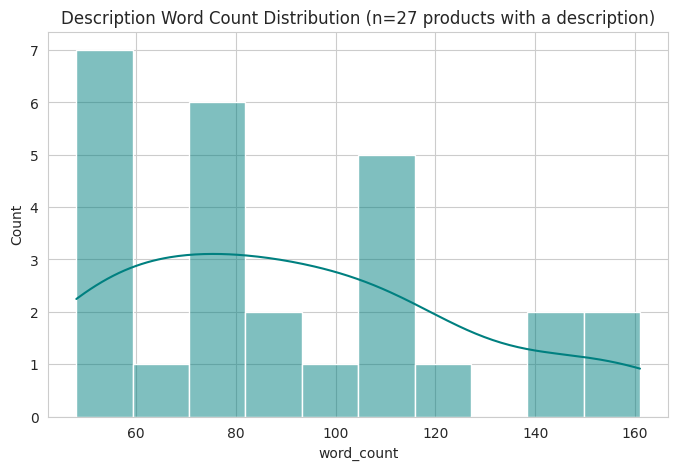

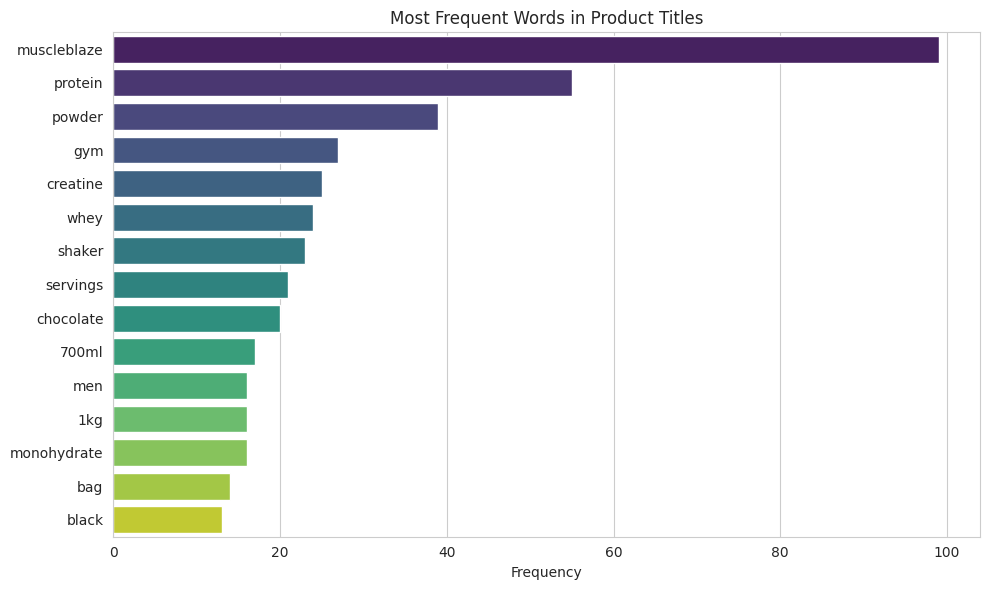

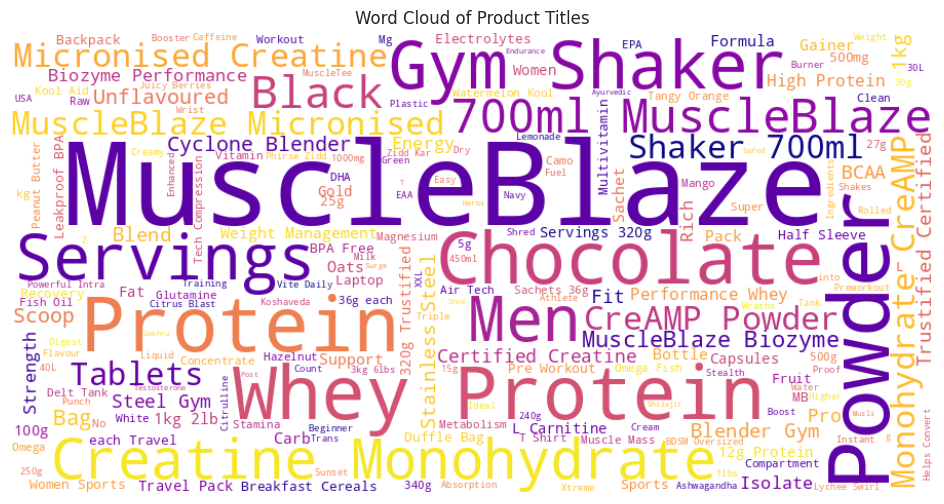

In [ ]:
desc_df = am[am['has_description']].copy()
desc_df['word_count'] = desc_df['description_clean'].str.split().str.len()

if len(desc_df) > 0:
    plt.figure(figsize=(8, 5))
    sns.histplot(desc_df['word_count'], bins=10, kde=True, color='teal')
    plt.title(f'Description Word Count Distribution (n={len(desc_df)} products with a description)')
    plt.show()

    AM_STOPWORDS = {'the','a','an','is','are','of','to','in','for','and','with','on','at','this','that',
                    'i','you','your','it','we','our','per','&','|'}
    all_words = ' '.join(am['title']).lower().split()
    all_words = [w.strip('|,()') for w in all_words if w.lower() not in AM_STOPWORDS and len(w) > 2]
    word_freq = Counter(all_words).most_common(15)
    words, counts = zip(*word_freq)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words), palette='viridis')
    plt.title('Most Frequent Words in Product Titles')
    plt.xlabel('Frequency')
    plt.tight_layout()
    plt.show()

    wordcloud = WordCloud(width=900, height=450, background_color='white',
                           stopwords=AM_STOPWORDS, colormap='plasma').generate(' '.join(am['title']))
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Product Titles')
    plt.show()
else:
    print("No descriptions available to analyze.")

## 6. Handle Outliers

In [ ]:
for col in ['price/value', 'reviewsCount']:
    flags = iqr_outlier_flags(am[col])
    print(f"{col}: {flags.sum()} outliers ({flags.mean()*100:.1f}%)")

am['is_price_outlier'] = iqr_outlier_flags(am['price/value'])
am['is_reviews_outlier'] = iqr_outlier_flags(am['reviewsCount'])

display(am[am['is_reviews_outlier']][['title','price/value','stars','reviewsCount']].sort_values('reviewsCount', ascending=False))

price/value: 14 outliers (14.0%)
reviewsCount: 12 outliers (12.0%)


,title,price/value,stars,reviewsCount
5,MuscleBlaze Micronised Creatine Monohydrate Cr...,549.0,4.2,24385.0
3,MuscleBlaze Weight Gainer Powder with Added Di...,989.0,3.8,11183.0
12,MuscleBlaze Omega 3 Fish Oil (90 Capsules) | T...,709.0,4.3,10779.0
77,"MuscleBlaze Mass Gainer XXL Powder, Chocolate ...",1269.0,3.8,10241.0
68,MuscleBlaze 100% Clean Raw Whey Protein Isolat...,2499.0,4.1,7796.0
38,"MuscleBlaze Fit High Protein Peanut Butter, Cr...",555.0,4.3,6500.0
60,"MuscleBlaze Super Gainer XXL Powder, Chocolate...",3049.0,3.8,6006.0
83,"MuscleBlaze 100% Whey Protein, Ultra Premium B...",2999.0,4.1,5507.0
41,"MuscleBlaze L-Carnitine L-Tartrate for Adults,...",809.0,3.9,4267.0
13,MuscleBlaze Biozyme Performance Whey Protein P...,6699.0,4.2,4214.0


**Decision:** the price outliers are legitimate premium SKUs (large-pack whey isolates, bundles) and the
review-count outliers are the brand's genuine bestsellers — both are kept, not removed, since trimming them
would erase the very products a business analysis should highlight.

## 7. Communicate Findings — Amazon

- The catalog is dominated by **Whey/Protein Powder** and other supplement categories, with a smaller slice
  of apparel & gear — pricing rises with product sophistication (isolates > concentrates > accessories).
- `reviewsCount` is **extremely right-skewed**: a handful of hero SKUs (the long-running whey/creatine
  staples) account for a disproportionate share of all reviews — classic Pareto pattern in an Amazon catalog.
- There is **no strong linear relationship between price and star rating** in this catalog — the correlation
  heatmap shows price is largely uncorrelated with rating, but higher review-count is a very weak positive
  signal (older/more established SKUs earn more reviews, not necessarily better ones).
- **Limitation:** the "category" field was derived from title keywords, not curated data, so a handful of
  products may be mis-bucketed under "Other" — this should be treated as an approximation, not ground truth.


# Overall Summary & Business Takeaways

Putting the three datasets side by side:

1. **Content that performs:** Both YouTube and Instagram show the same pattern — a small number of pieces of
   content (viral videos / high-engagement Reels) drive a disproportionate share of total reach and
   engagement. Video-format content (YouTube videos, Instagram Reels) consistently outperforms static/carousel
   content.
2. **Discovery levers:** Hashtags are barely used on either platform for this brand, so they are not currently
   a meaningful growth lever — if hashtag strategy hasn't been tested deliberately, it may be worth an
   A/B test rather than assuming it doesn't work.
3. **Tone:** Captions and titles skew positive/neutral and motivational across both platforms, which is
   consistent, on-brand messaging.
4. **Commerce:** On Amazon, a handful of hero SKUs (whey protein, creatine) carry most of the review volume —
   these are the products most worth protecting (stock, pricing, ad spend) since they anchor the brand's
   on-platform reputation.
5. **Cross-cutting limitation:** every dataset covers a **single brand**, so none of these findings can be
   generalized to "fitness content" or "supplement listings" broadly — they describe MuscleBlaze specifically,
   which is exactly the audience/business this analysis serves.
